In [1]:
# Cell 1 : Setup & Imports
import json
import time
import datetime
import pathlib
import pickle

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow_probability.substrates.jax.bijectors as tfb

import sys
import pathlib

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)

# Make the project root importable so `from src.x import ...` resolves
# regardless of how deep this notebook sits.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project imports rely on the package being installed in the uv environment
# (uv run / editable install), so they resolve regardless of notebook depth.
from src.mixturemodel import build_mixture_hbmnl_model
from src.inference.nuts import run_nuts_inference_mixture_hbmnl
from src.analysis import (
    plot_cholesky_traces,
    plot_goose_style_diagnostics,
    recover_covariance_matrices,
    plot_final_covariance_complete,
    summarize_mu_k,
    generate_delta_summaries,
    plot_delta_distributions,
    plot_beta_scatter,
    plot_beta_distributions,
    plot_pvec_diagnostics,
    summarize_pvec,
    export_posterior_to_pickle,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)



print(f"Project root : {project_root}")
print("Imports successful!")




Project root : c:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL
Imports successful!


In [2]:
# Cell 2 : Load Data
# choice_data holds observations + ground truth only. It has NO "K" key:
# the number of model components is a modelling decision made in Cell 3.

SCENARIO_NAME = "2comp_equal"   # e.g. 1comp / 2comp_equal / 3comp_equal / 5comp_equal

data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"

with open(data_path, "r") as f:
    raw_data = json.load(f)

# True number of components — standalone scalar, never placed in choice_data.
K_TRUE = int(raw_data["K"])

choice_data = {
    # observed data
    "X":        jnp.array(raw_data["X"]),
    "y":        jnp.array(raw_data["y"]),
    "unit_idx": jnp.array(raw_data["unit_idx"]),
    "Z":        jnp.array(raw_data["Z"]) if raw_data.get("Z") is not None else None,
    # dimensions
    "n_params": int(raw_data["n_params"]),
    "n_units":  int(raw_data["n_units"]),
    "n_demos":  int(raw_data.get("n_demos", 0)),
    # ground truth (diagnostics only — never read by the model or sampler)
    "TRUE_DELTA":      np.array(raw_data["TRUE_DELTA"])      if "TRUE_DELTA"      in raw_data else None,
    "TRUE_BETA":       np.array(raw_data["TRUE_BETA"])       if "TRUE_BETA"       in raw_data else None,
    "TRUE_PVEC":       np.array(raw_data["TRUE_PVEC"])       if "TRUE_PVEC"       in raw_data else None,
    "TRUE_MU_K":       np.array(raw_data["TRUE_MU_K"])       if "TRUE_MU_K"       in raw_data else None,
    "TRUE_SIGMA_K":    np.array(raw_data["TRUE_SIGMA_K"])    if "TRUE_SIGMA_K"    in raw_data else None,
    "TRUE_INDICATORS": np.array(raw_data["TRUE_INDICATORS"]) if "TRUE_INDICATORS" in raw_data else None,
}

assert "K" not in choice_data, "choice_data must not carry a K key."

print(f"Scenario           : {SCENARIO_NAME}")
print(f"Units (N)          : {choice_data['n_units']}")
print(f"Parameters (P)     : {choice_data['n_params']}")
print(f"K in data (K_TRUE) : {K_TRUE}")
if choice_data["TRUE_PVEC"] is not None:
    print(f"TRUE_PVEC          : {choice_data['TRUE_PVEC'].round(4)}")


Scenario           : 2comp_equal
Units (N)          : 300
Parameters (P)     : 4
K in data (K_TRUE) : 2
TRUE_PVEC          : [0.5 0.5]


In [3]:
# Cell 3 : Model Configuration & Build
# model_cfg is the single source of truth for all modelling decisions.

model_cfg = {
    "K_MODEL":     5,       # number of components the MODEL fits (5 for now)
    "A_delta":     0.01,
    "a_mu":        0.01,
    "dirichlet_a": 1.0,     # 1.0 = uniform; use < 1.0 (e.g. 0.5) to encourage
                            # spurious components to collapse when K_MODEL > K_TRUE
}

K_MODEL = model_cfg["K_MODEL"]

print(f"Building {K_MODEL}-component model on {K_TRUE}-component data "
      f"(dirichlet_a={model_cfg['dirichlet_a']})...")

hmnl_model = build_mixture_hbmnl_model(
    data_dict=choice_data,
    K=K_MODEL,                       # explicit; decoupled from K_TRUE
    A_delta=model_cfg["A_delta"],
    a_mu=model_cfg["a_mu"],
    dirichlet_a=model_cfg["dirichlet_a"],
)

print("Model built successfully.")


Building 5-component model on 2-component data (dirichlet_a=1.0)...


c:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Model built successfully.


In [4]:
# Cell 4 : Run Inference
print(f"Starting NUTS sampling  (K_MODEL={K_MODEL}, K_TRUE={K_TRUE})...")
start_time = time.time()

mcmc_results, posterior_samples = run_nuts_inference_mixture_hbmnl(
    model=hmnl_model,
    data_dict=choice_data,
    K=K_MODEL,               # explicit K for correct logging; not read from data
    chains=1,
    warmup=2000,
    posterior=10000,
    seed=42,
)

elapsed = datetime.timedelta(seconds=int(time.time() - start_time))
print(f"\nInference completed in {elapsed}")


Starting NUTS sampling  (K_MODEL=5, K_TRUE=2)...


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS sampling for mixture HBMNL...
 - Demographic covariates (Delta) included : True
 - Model components (K_MODEL)              : 5
 - Chains: 1 | Warmup: 2000 | Posterior: 10000


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:35<00:00, 11.91s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 7 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 52 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 411.57chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1 /


Inference completed in 0:32:20


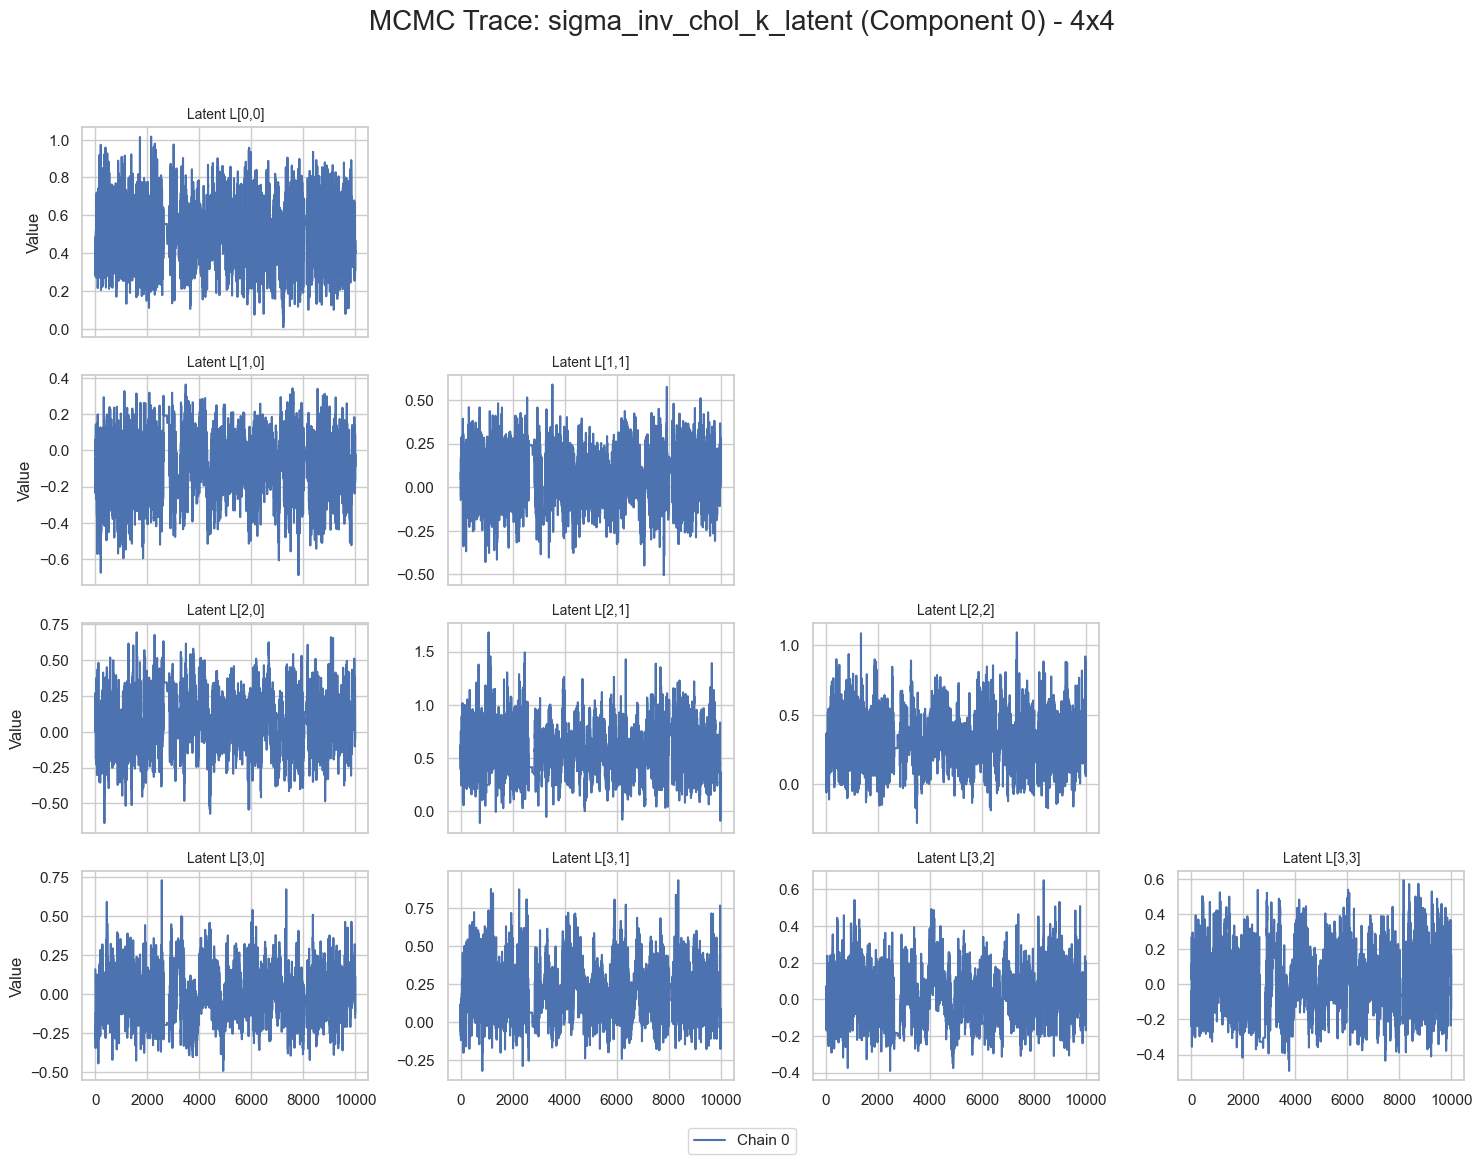

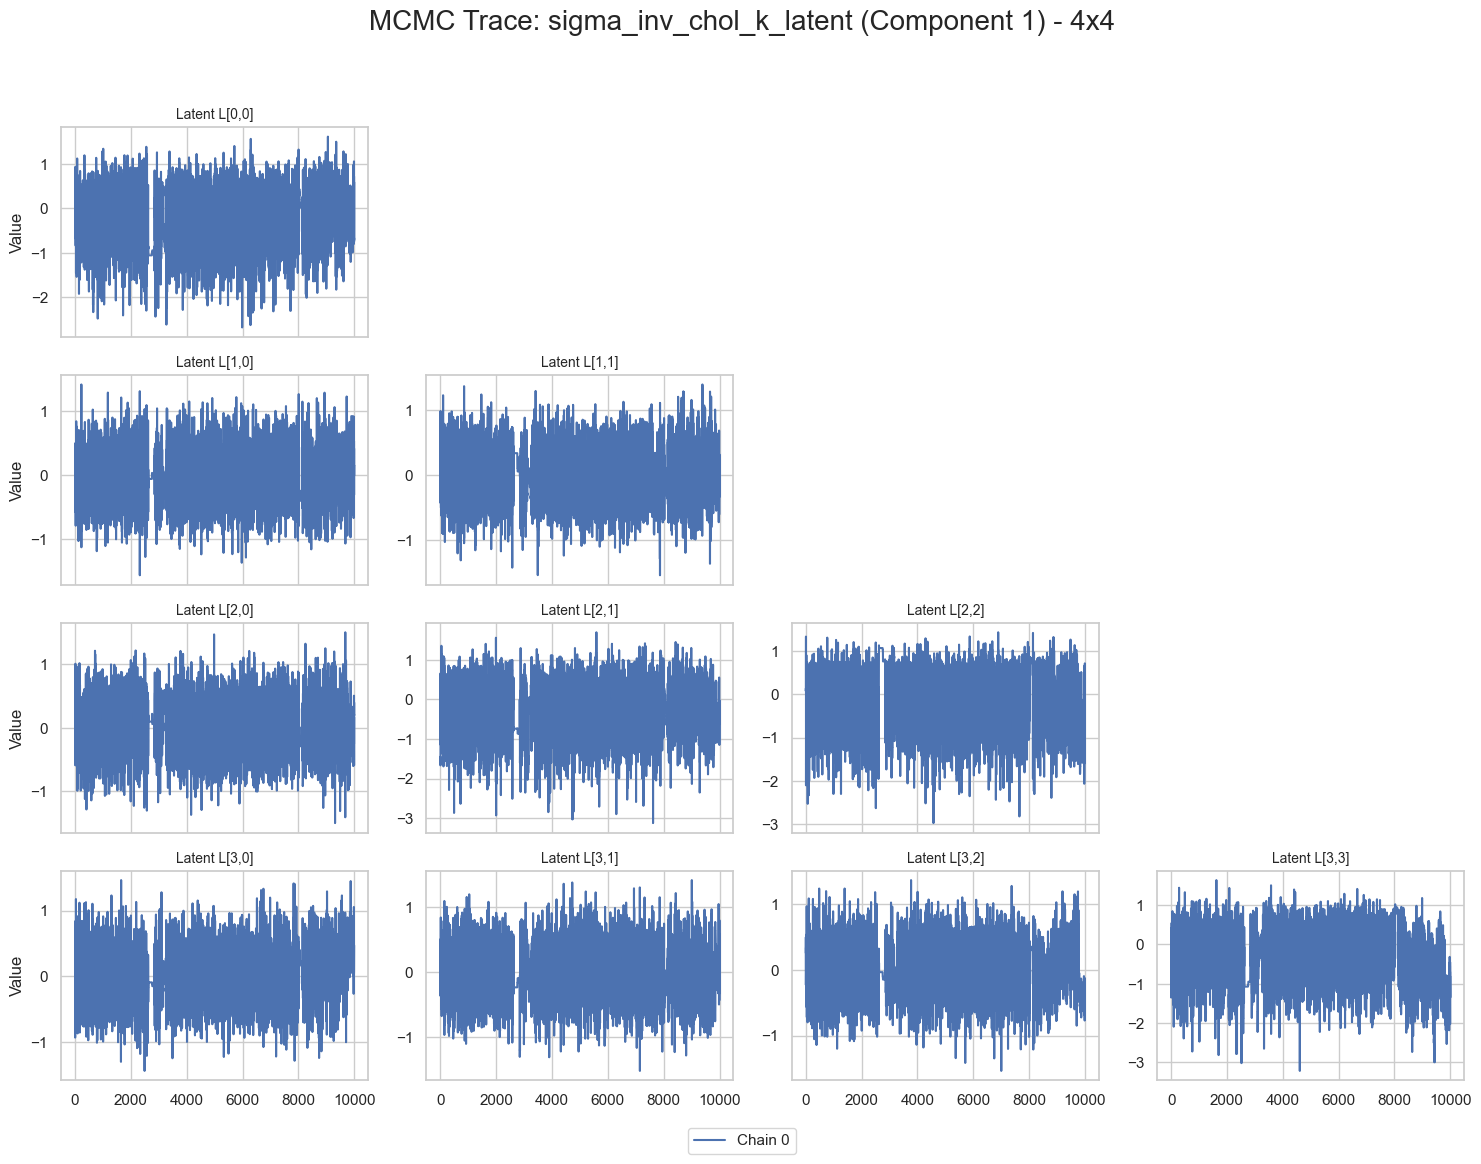

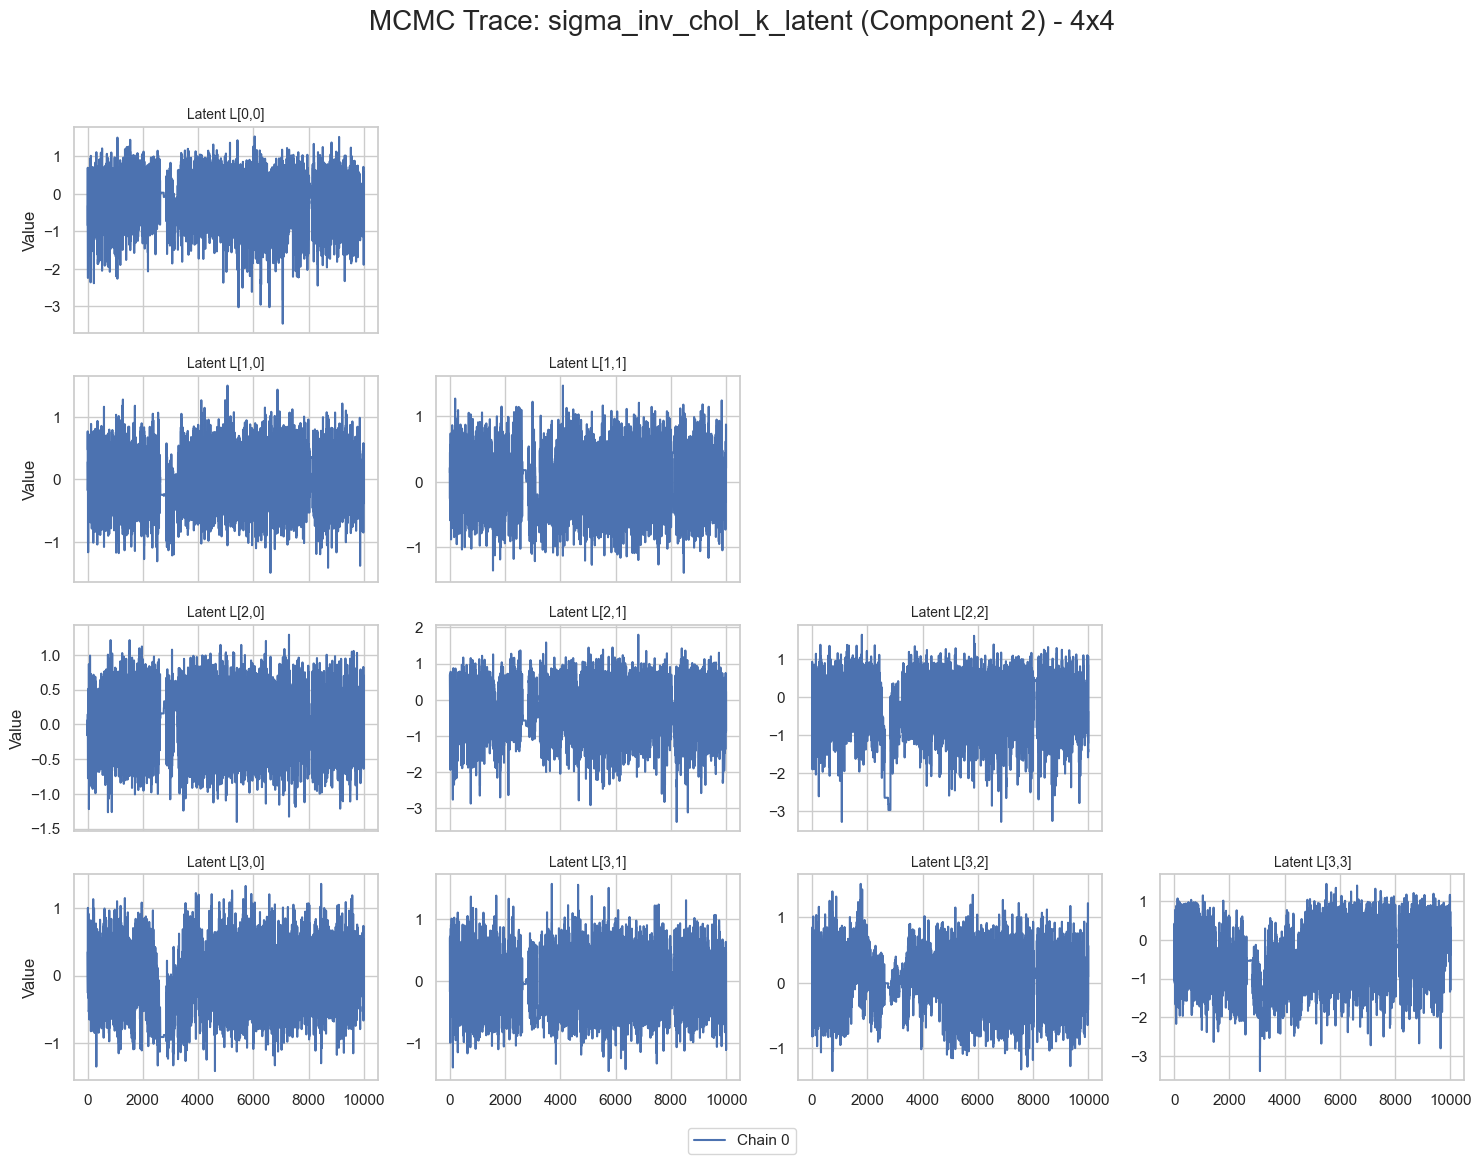

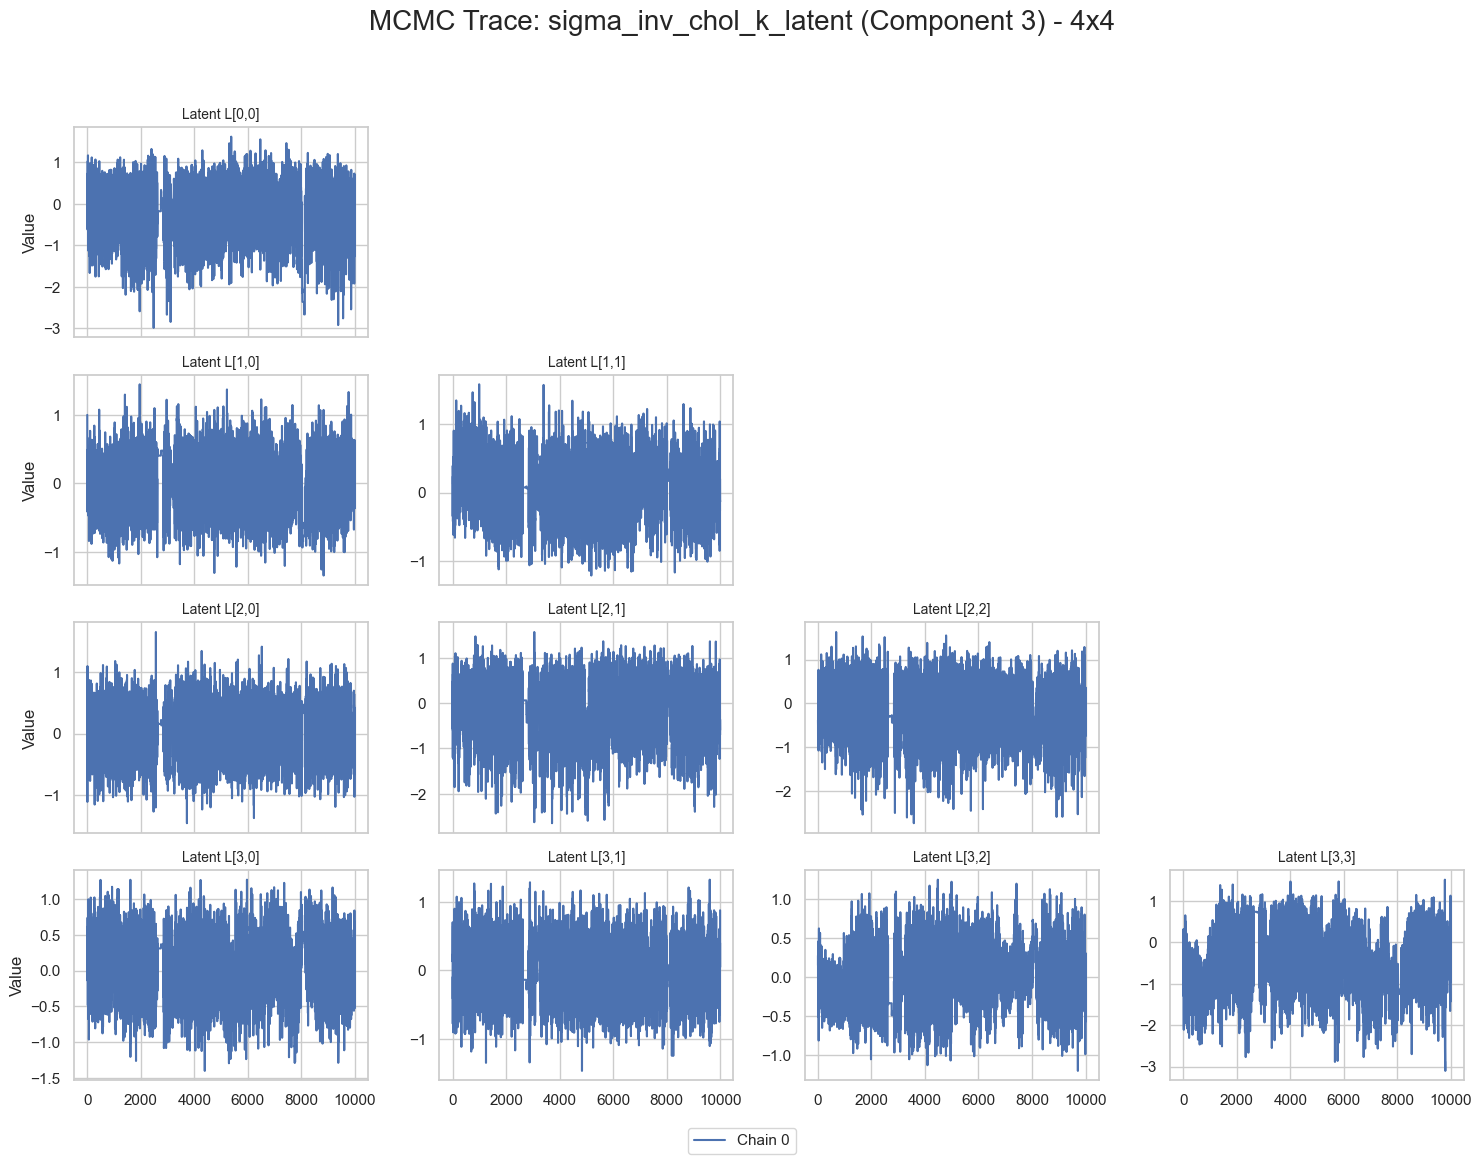

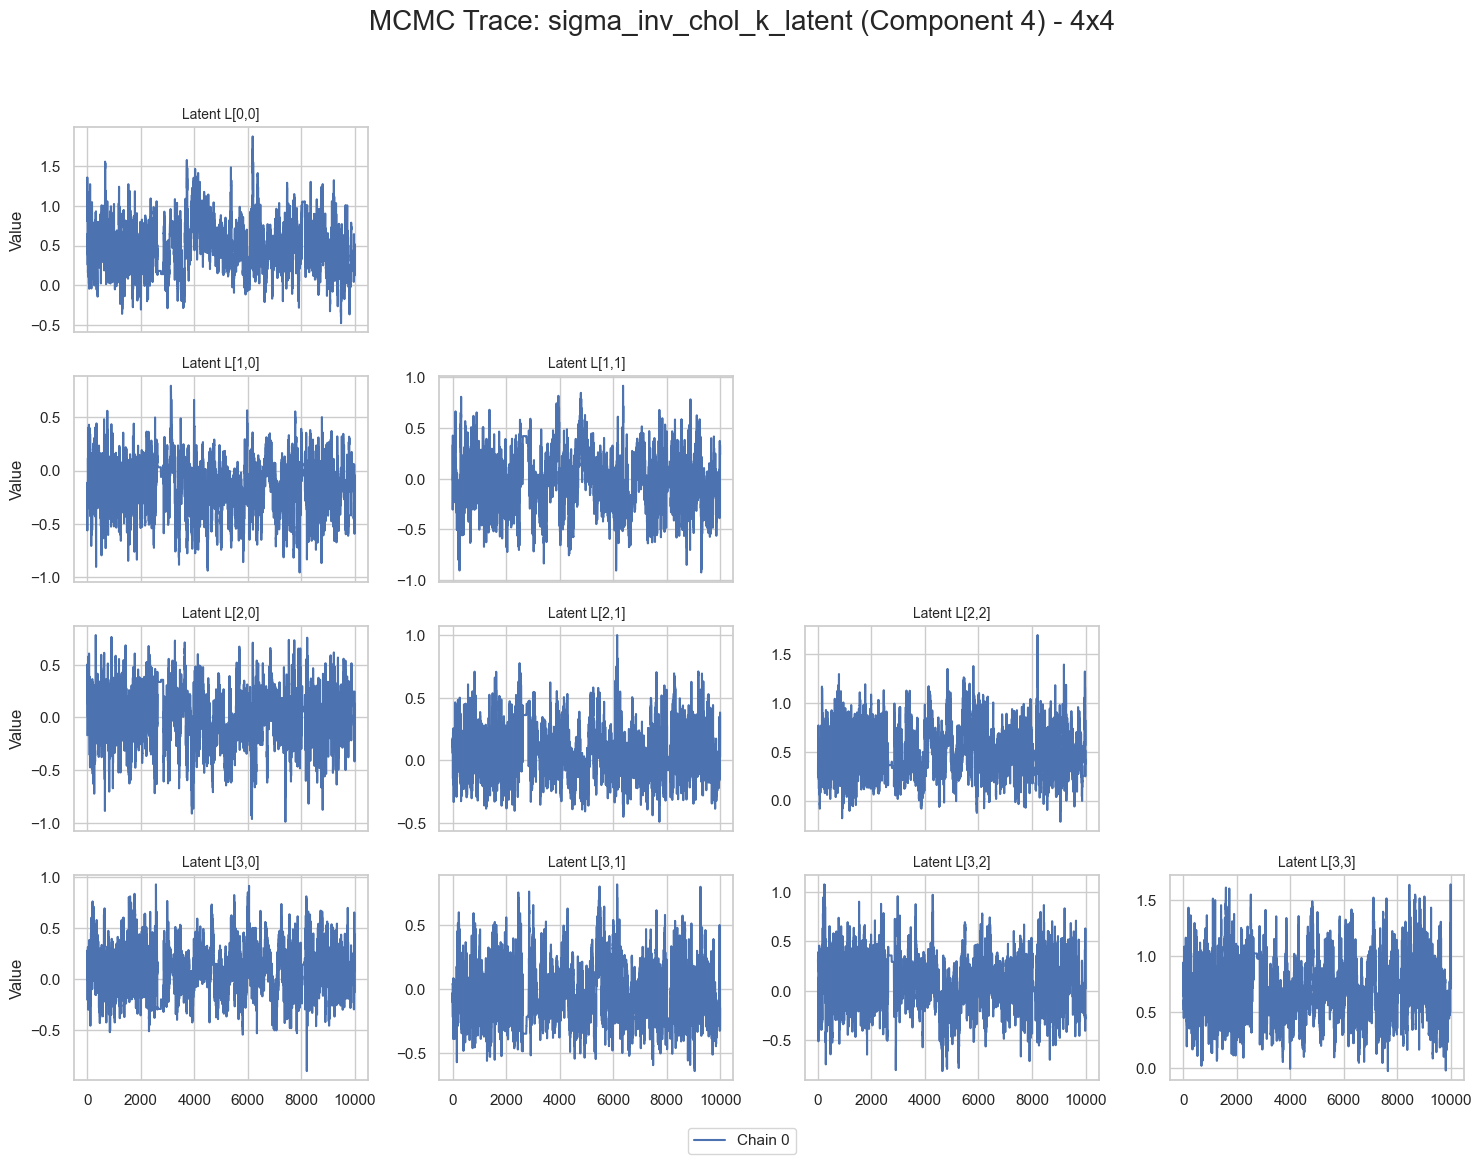


Recovering Covariance Matrices (Sigma_k)...


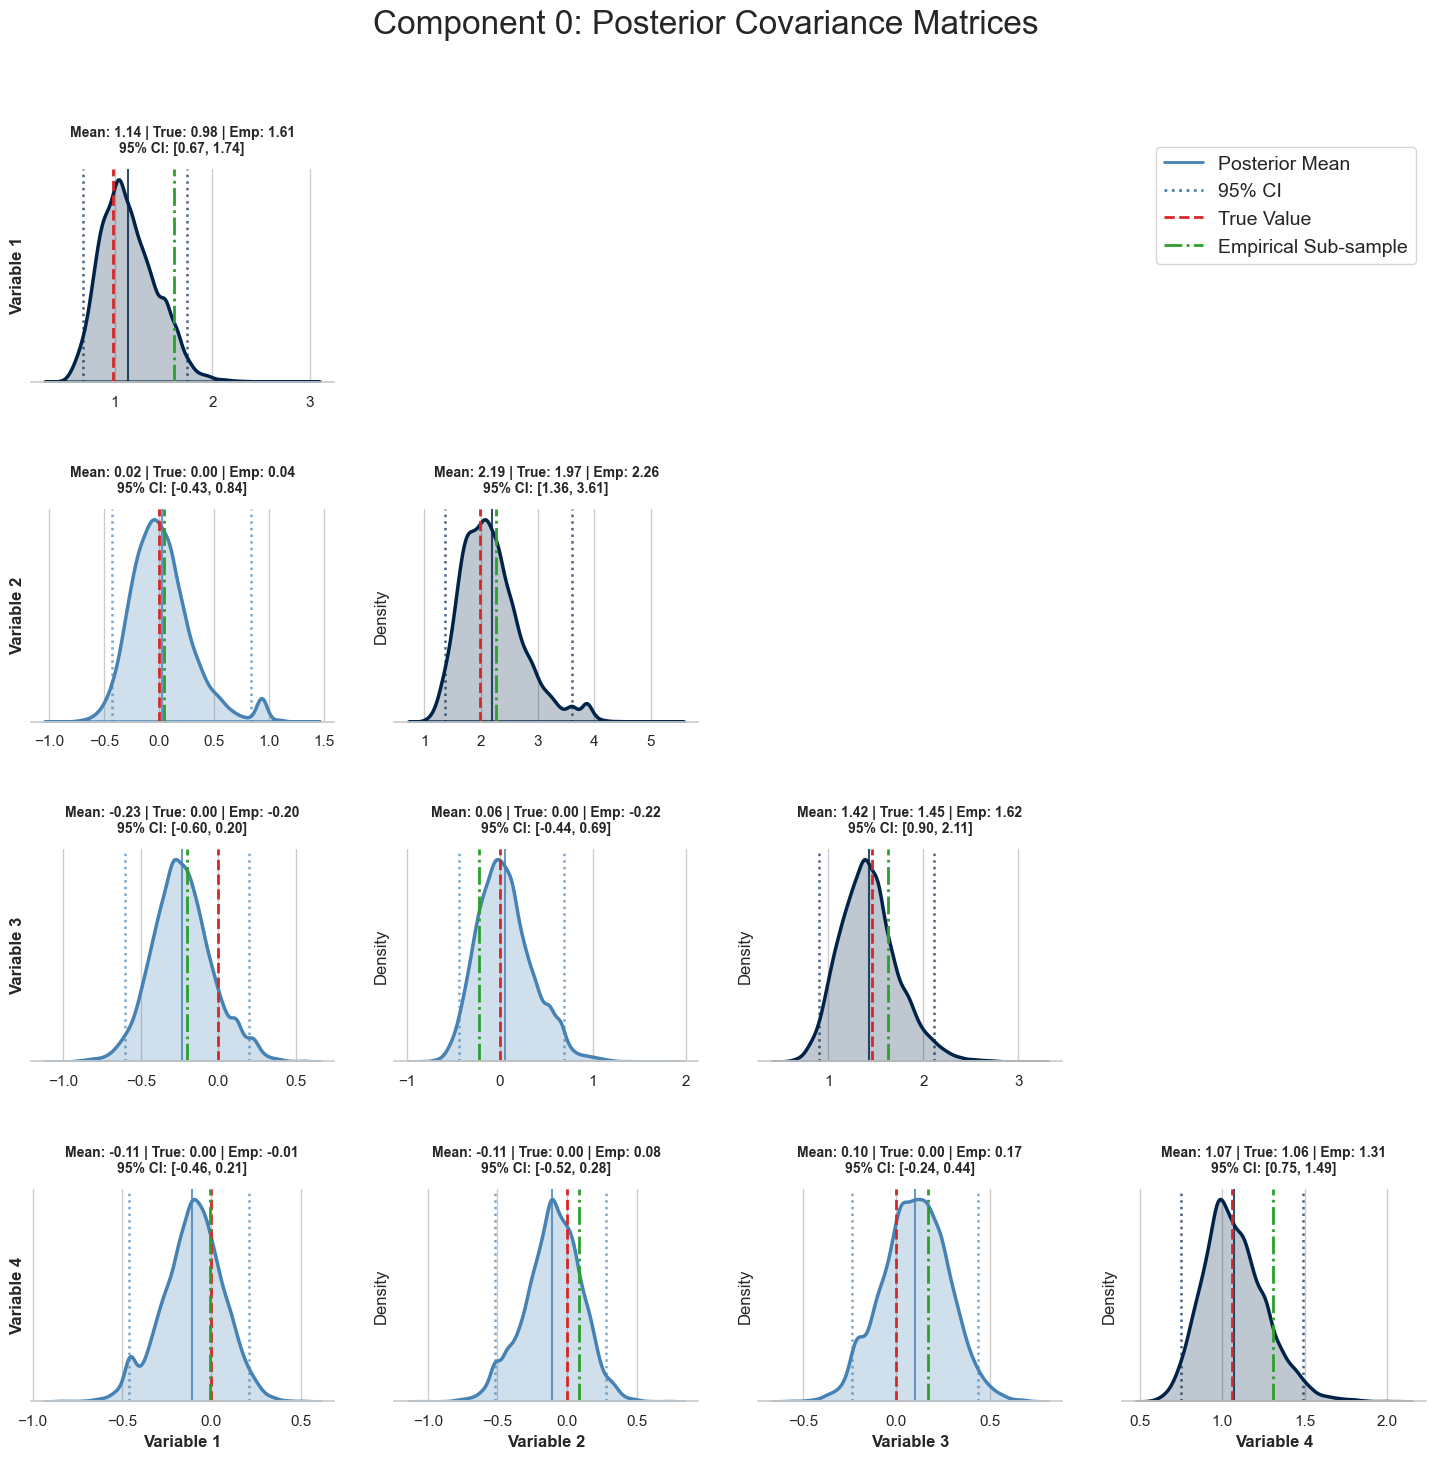

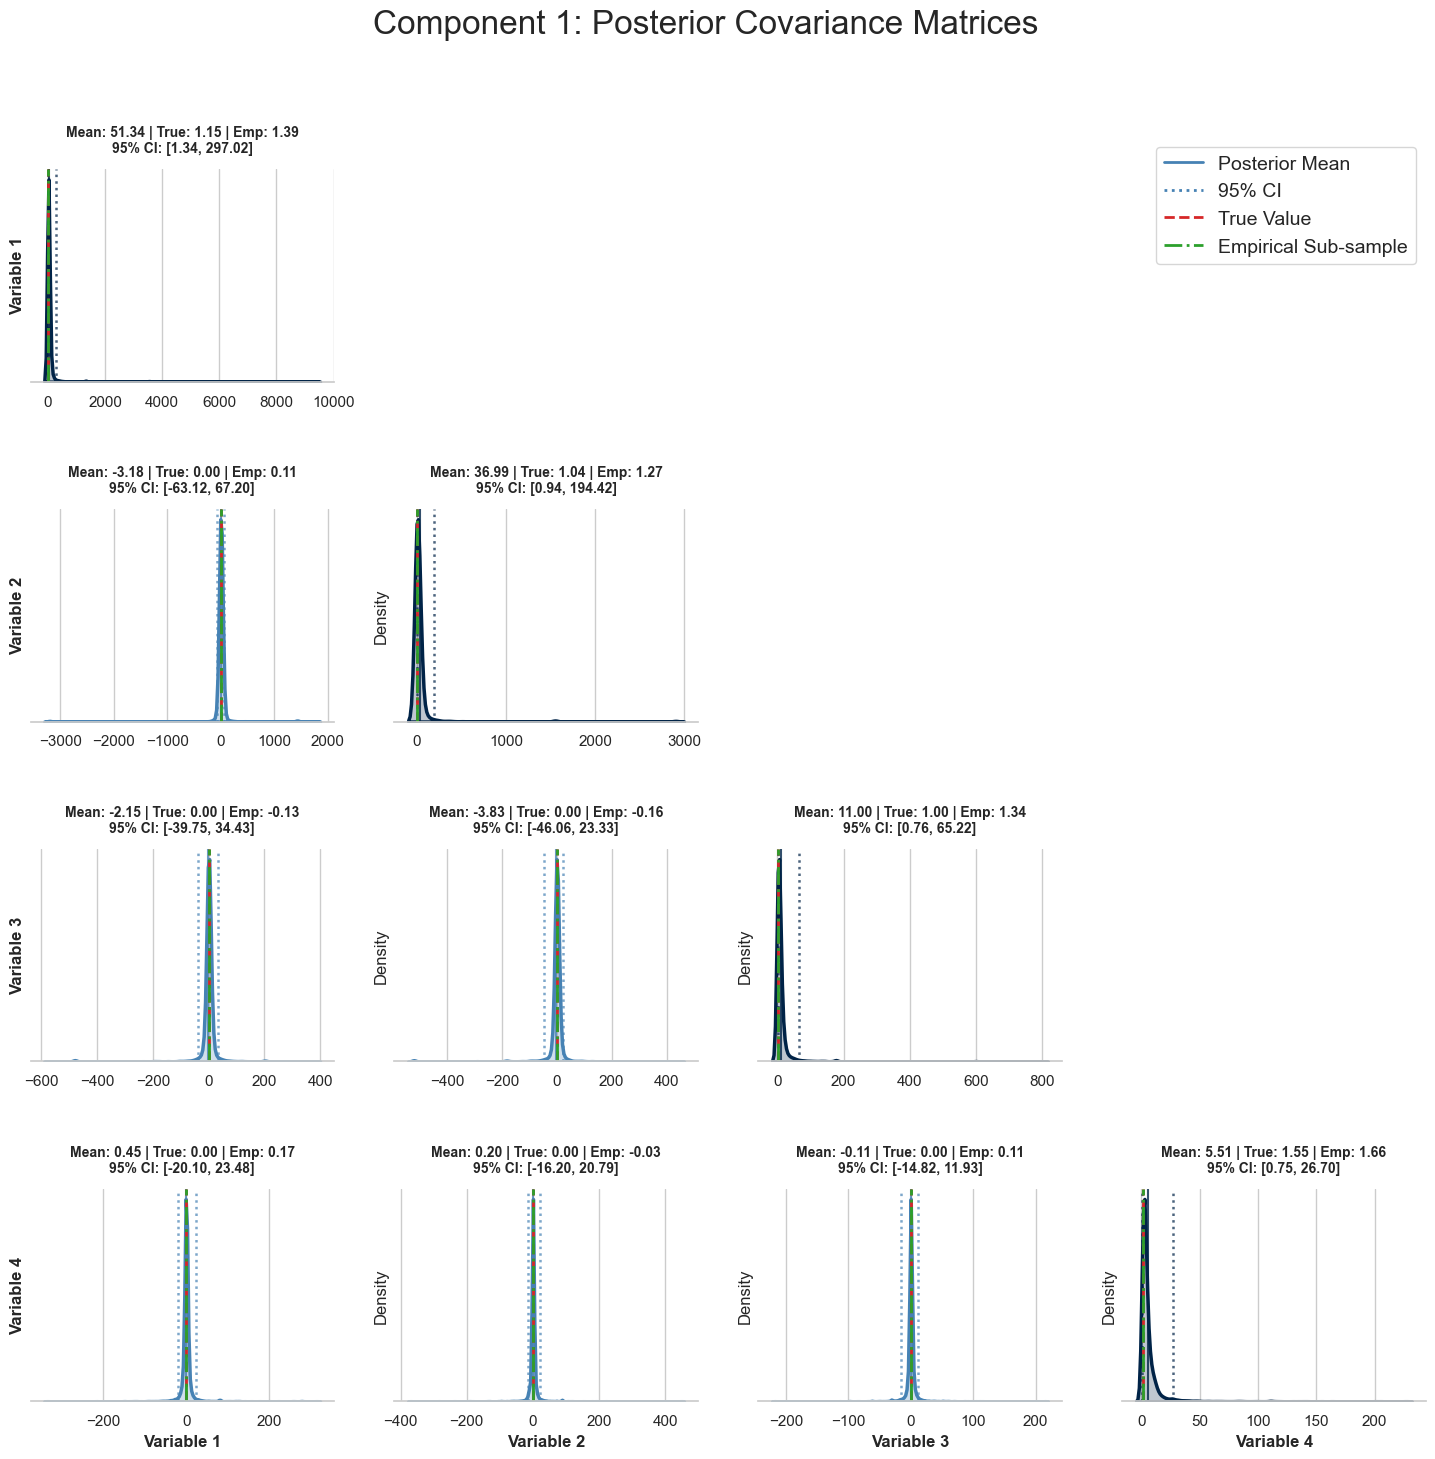

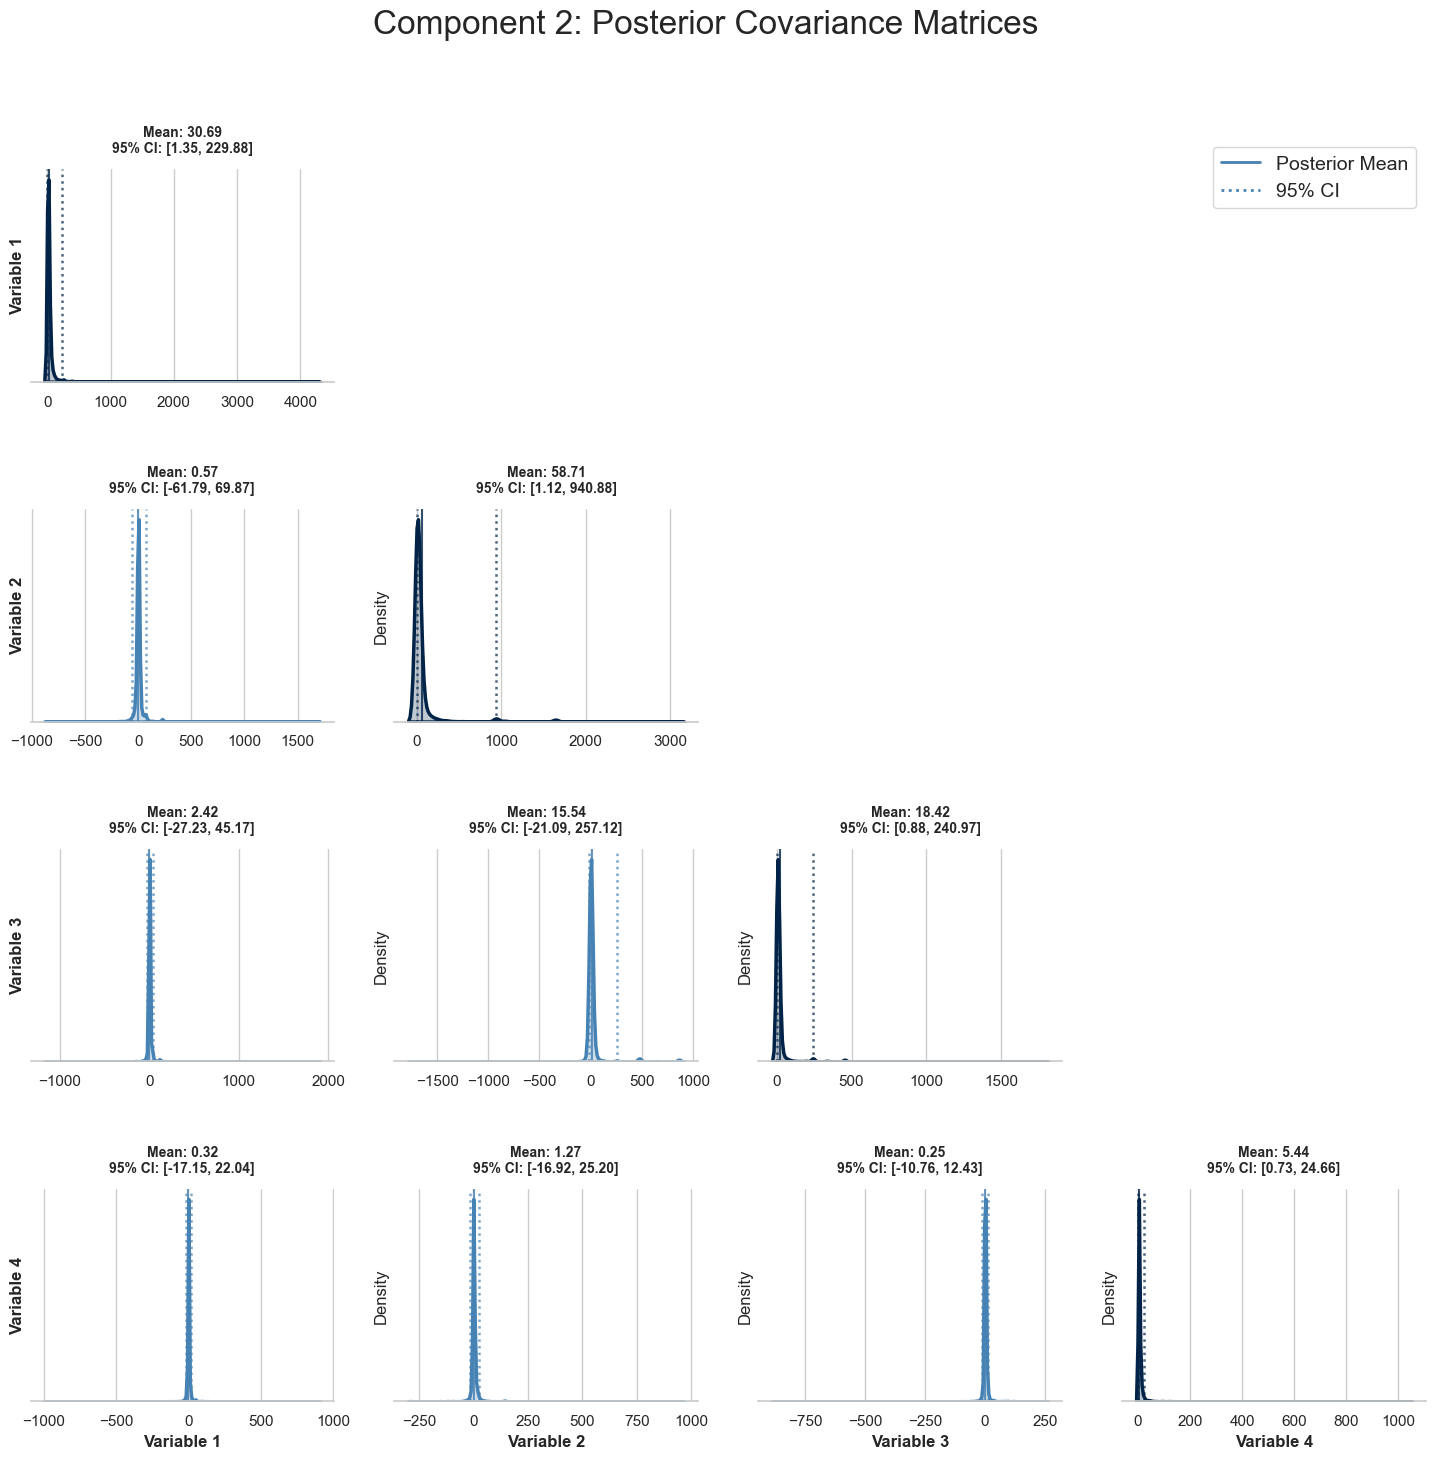

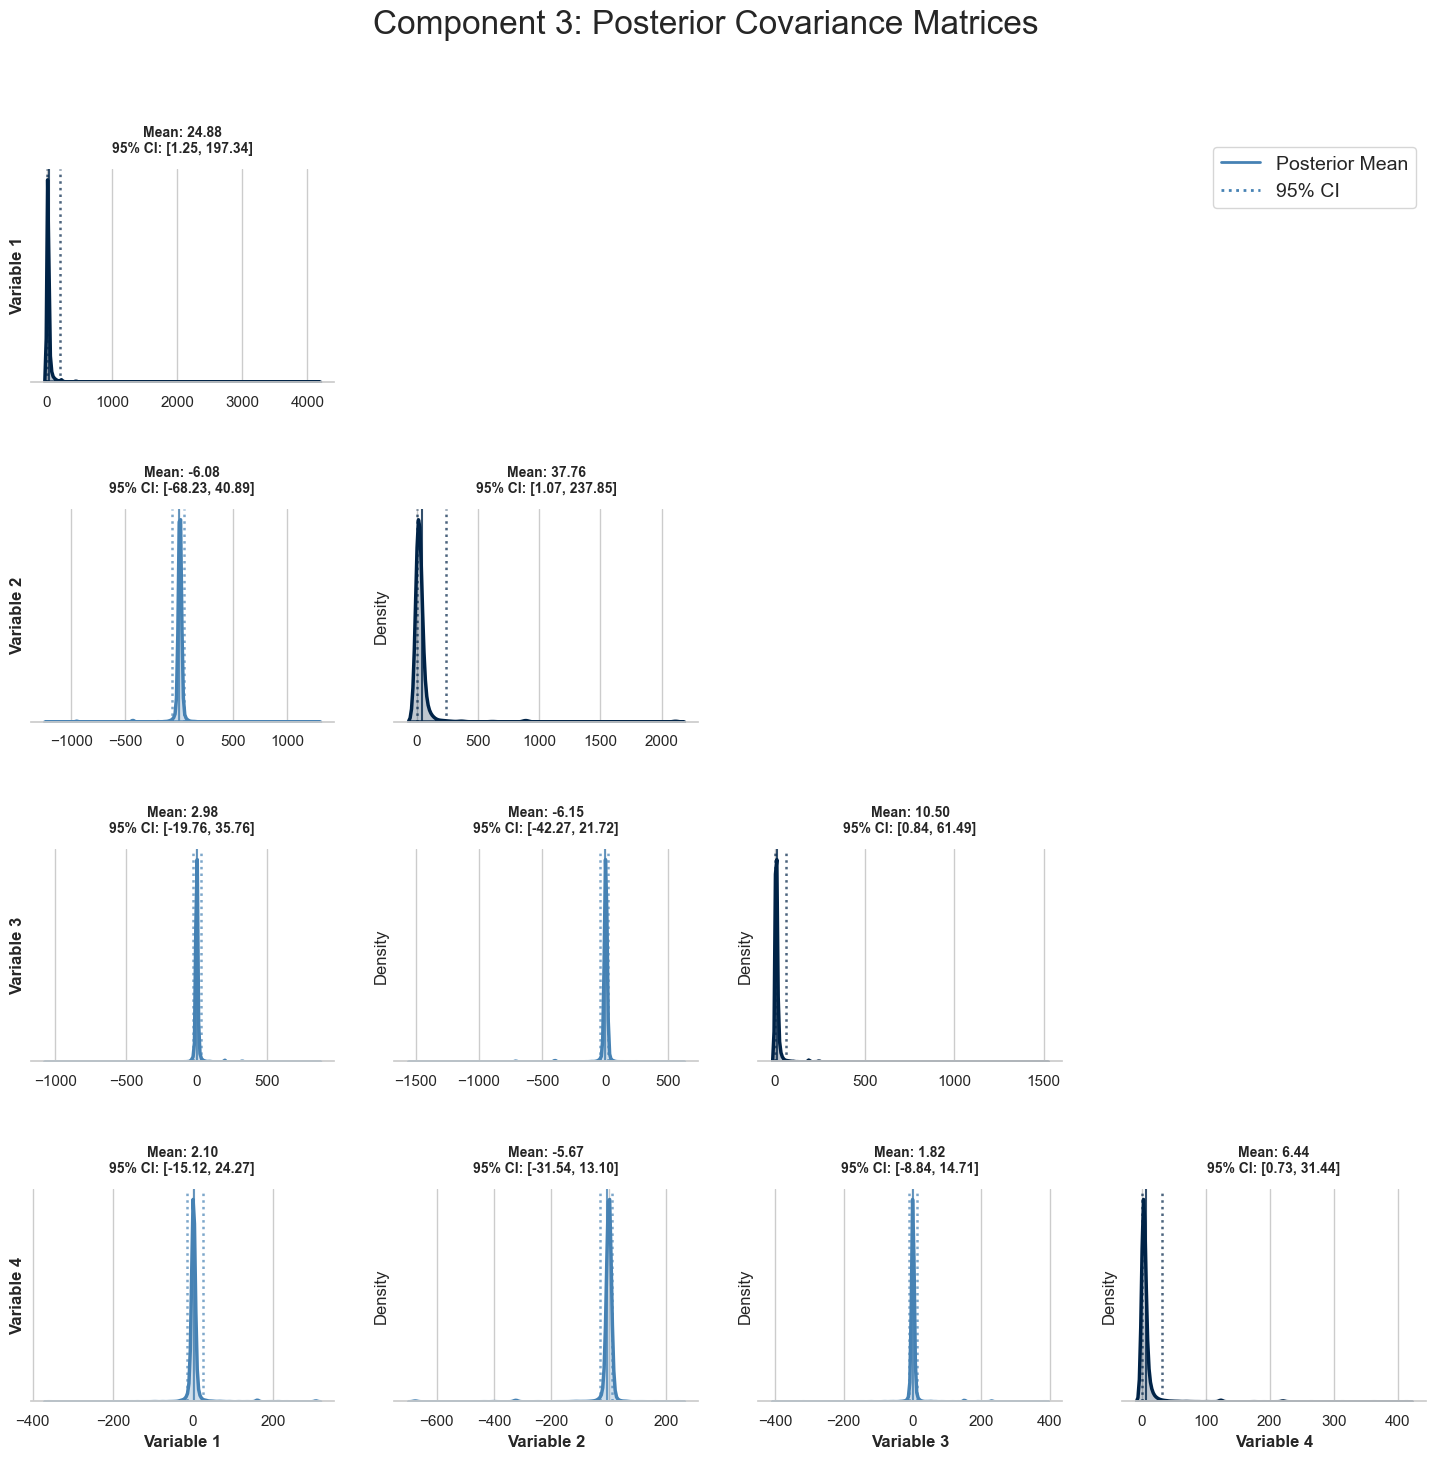

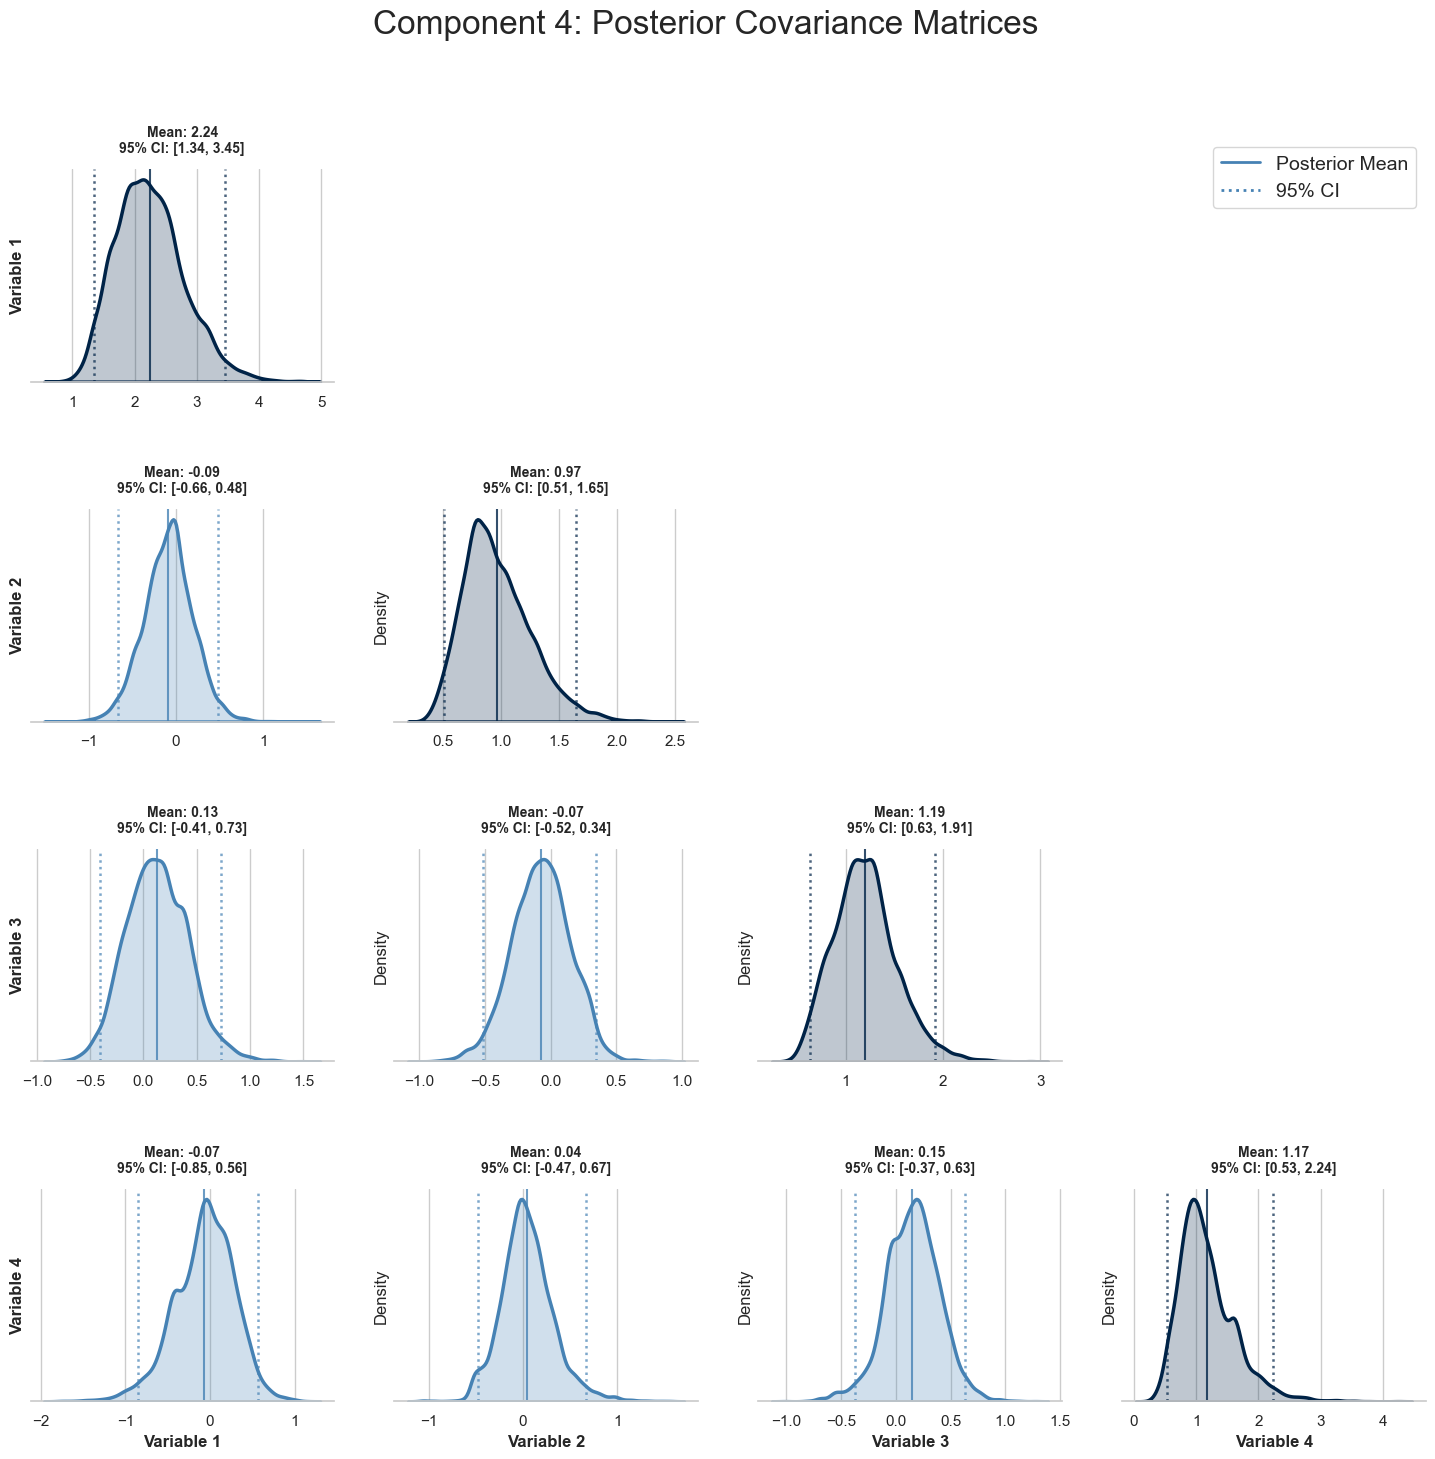


=== Component Means (mu_k) Summary Tables ===

--- MCMC Component 0 (matched to True Component 0) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,1.3489,1.2232,0.1436,0.1257
Param_1,4.0323,3.9328,0.1750,0.0994
Param_2,3.1409,3.0871,0.1525,0.0538
Param_3,-2.6595,-2.5476,0.1077,0.1119



--- MCMC Component 1 (spurious - no true counterpart) ---


,Posterior_Mean,Posterior_Std
Parameter,,
Param_0,1.8460,62.649200
Param_1,10.8254,49.072201
Param_2,-2.8157,30.316299
Param_3,-0.1614,22.201700



--- MCMC Component 2 (spurious - no true counterpart) ---


...


--- MCMC Component 3 (spurious - no true counterpart) ---


,Posterior_Mean,Posterior_Std
Parameter,,
Param_0,-2.4285,38.970600
Param_1,22.4566,50.093102
Param_2,-2.7873,24.484100
Param_3,-4.0692,19.712299



--- MCMC Component 4 (matched to True Component 1) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,3.2642,3.3432,0.1907,0.0790
Param_1,-2.4496,-2.3874,0.1756,0.0622
Param_2,1.5724,1.4974,0.1520,0.0751
Param_3,-7.2957,-7.4456,0.2720,0.1500



=== Goose-Style Diagnostics for Delta ===


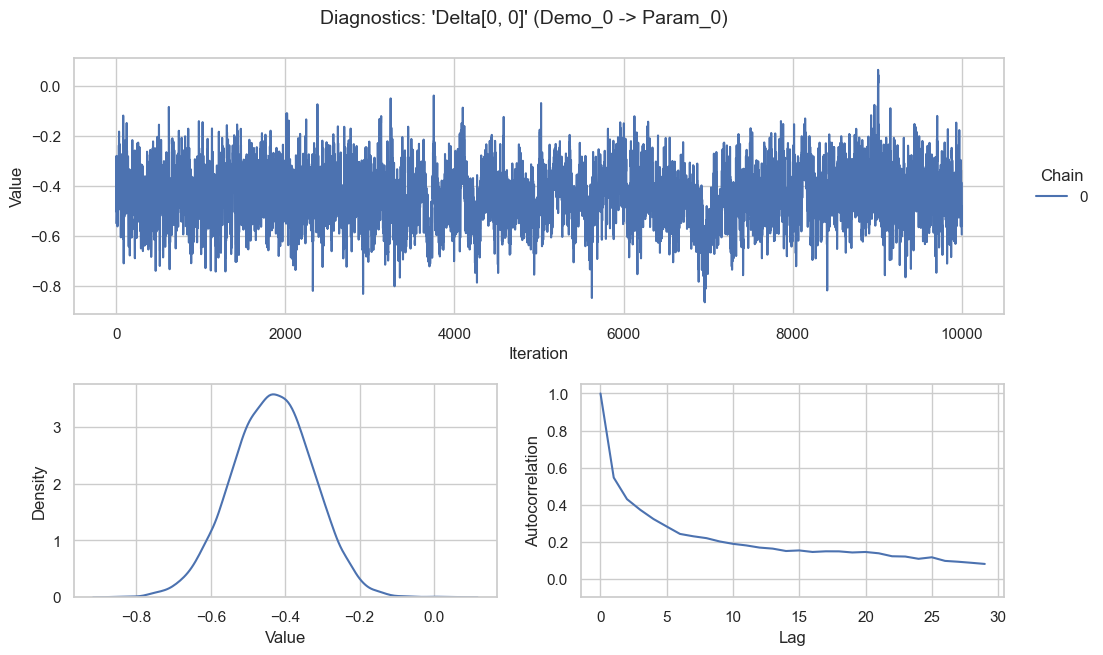

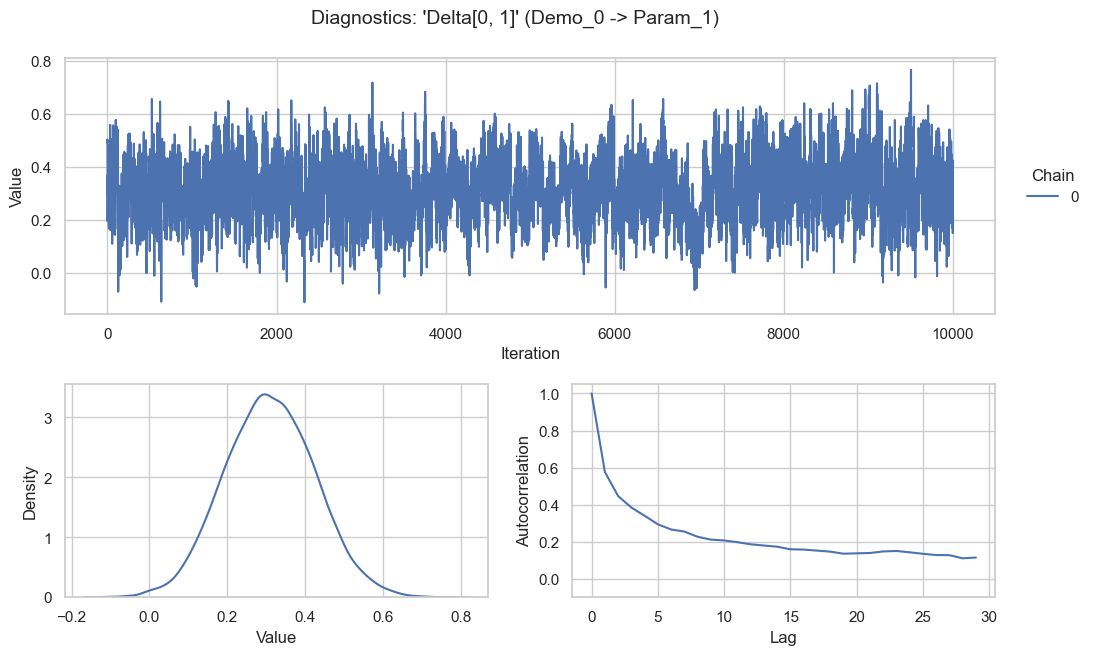

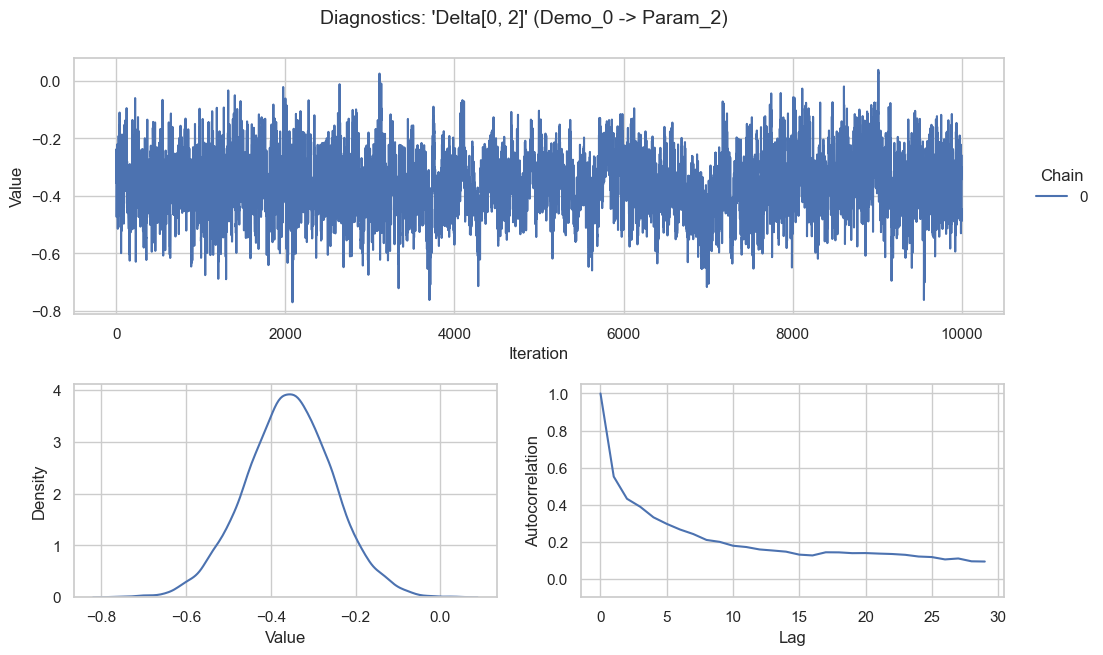

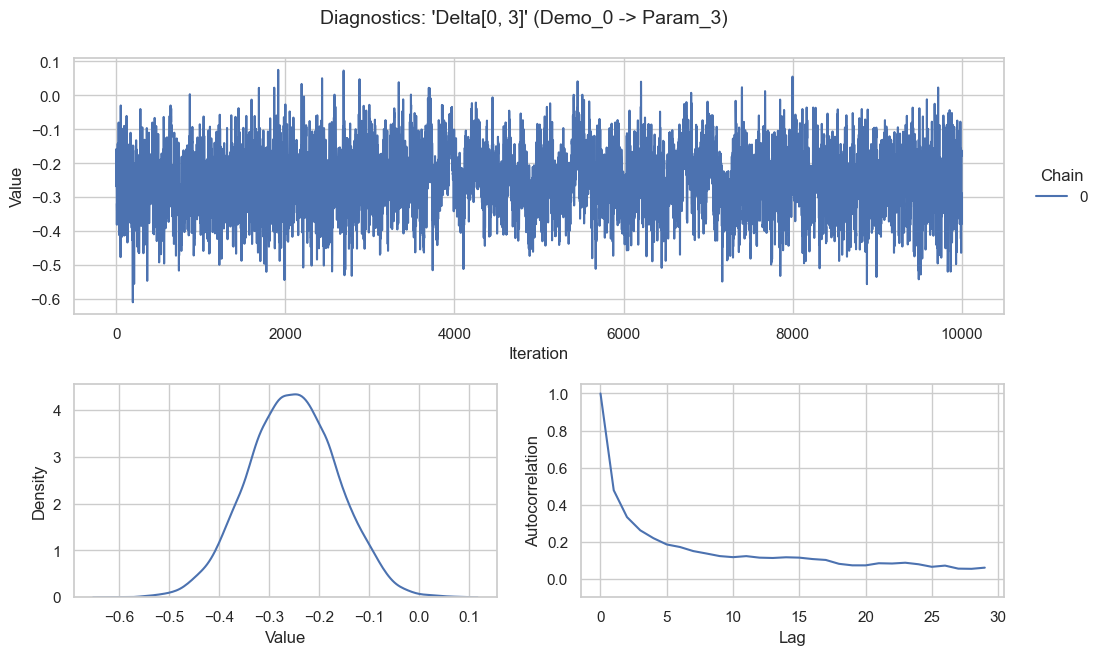

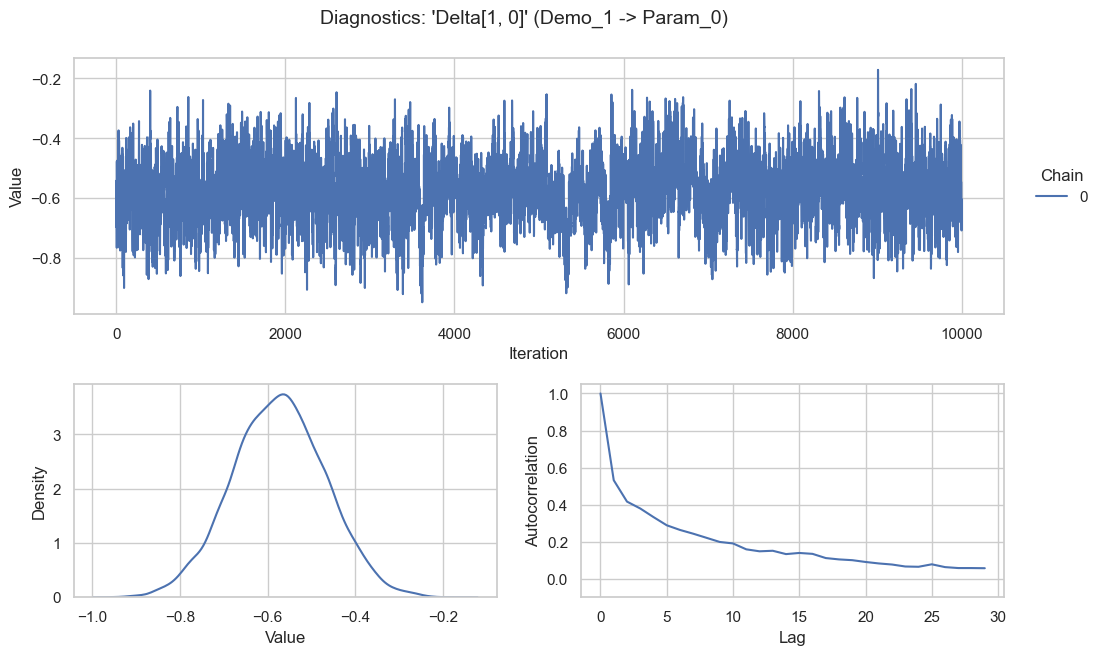

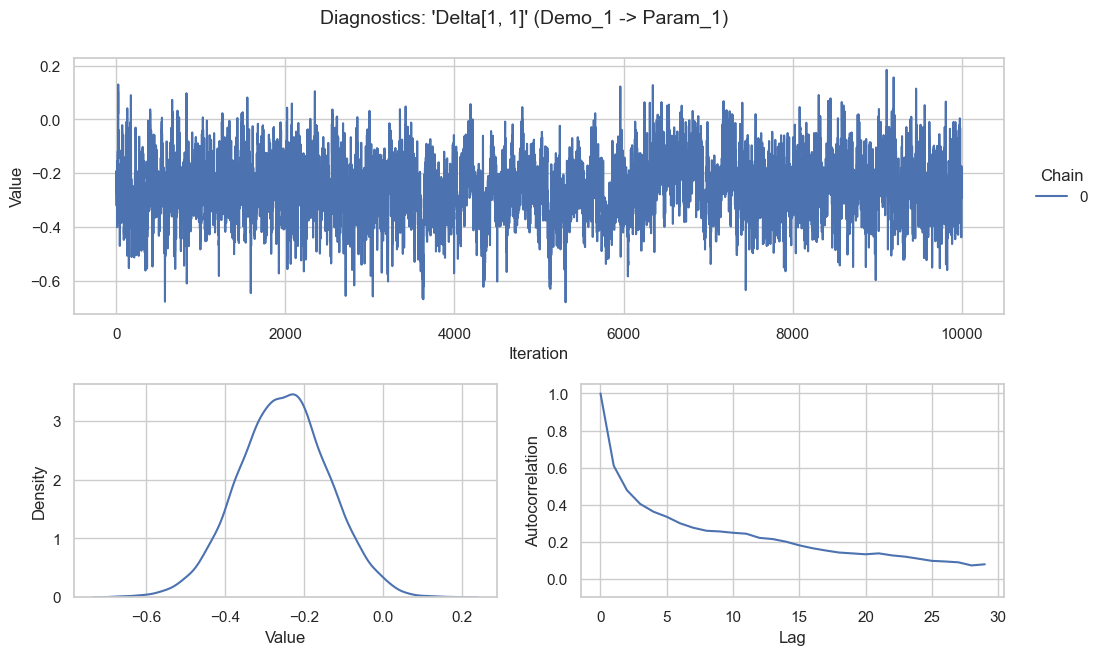

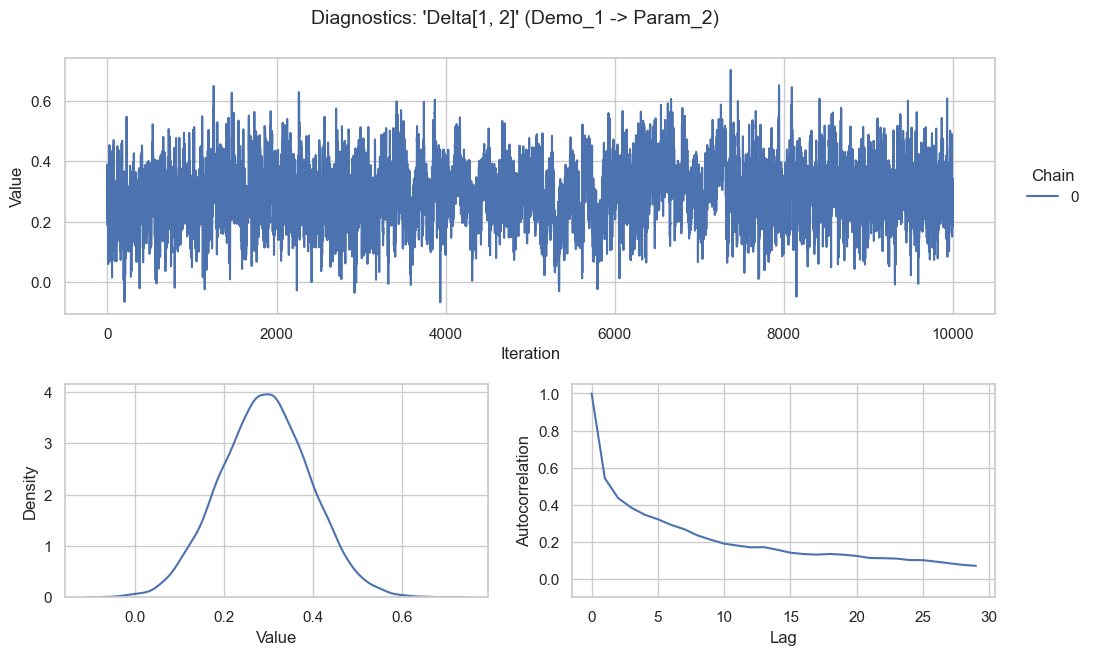

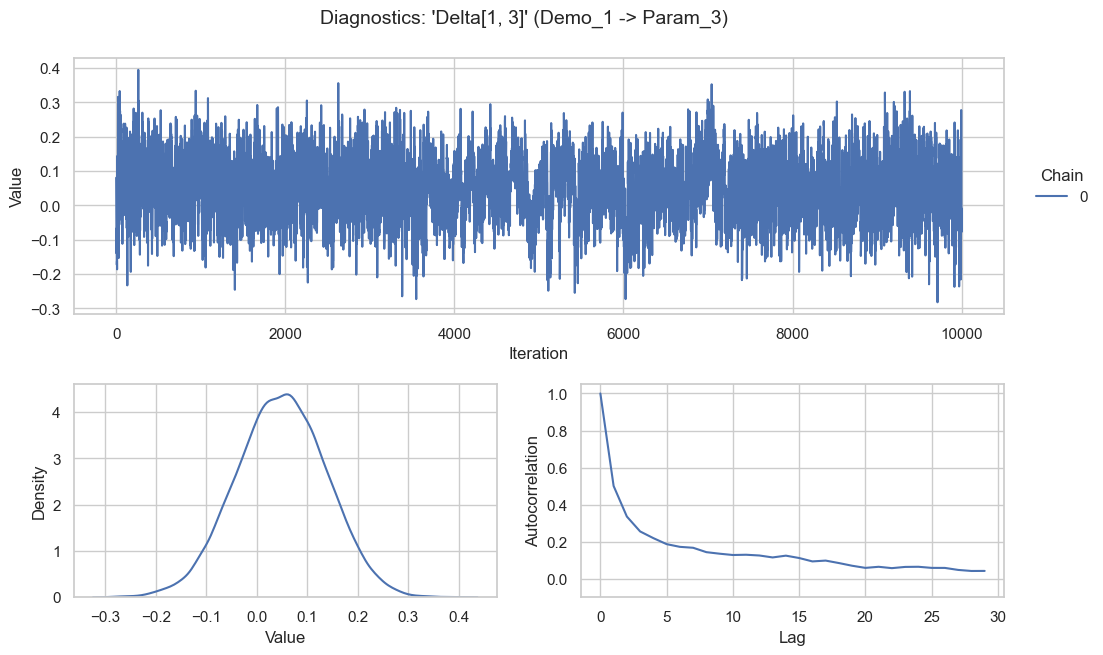


=== Posterior distribution of Delta (mean + std) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.43 (0.11),0.31 (0.12),-0.36 (0.10),-0.25 (0.09)
Demo_1,-0.57 (0.11),-0.25 (0.11),0.29 (0.10),0.05 (0.09)



=== Absolute Difference in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.101,0.062,0.119,0.007
Demo_1,0.156,0.006,0.116,0.083


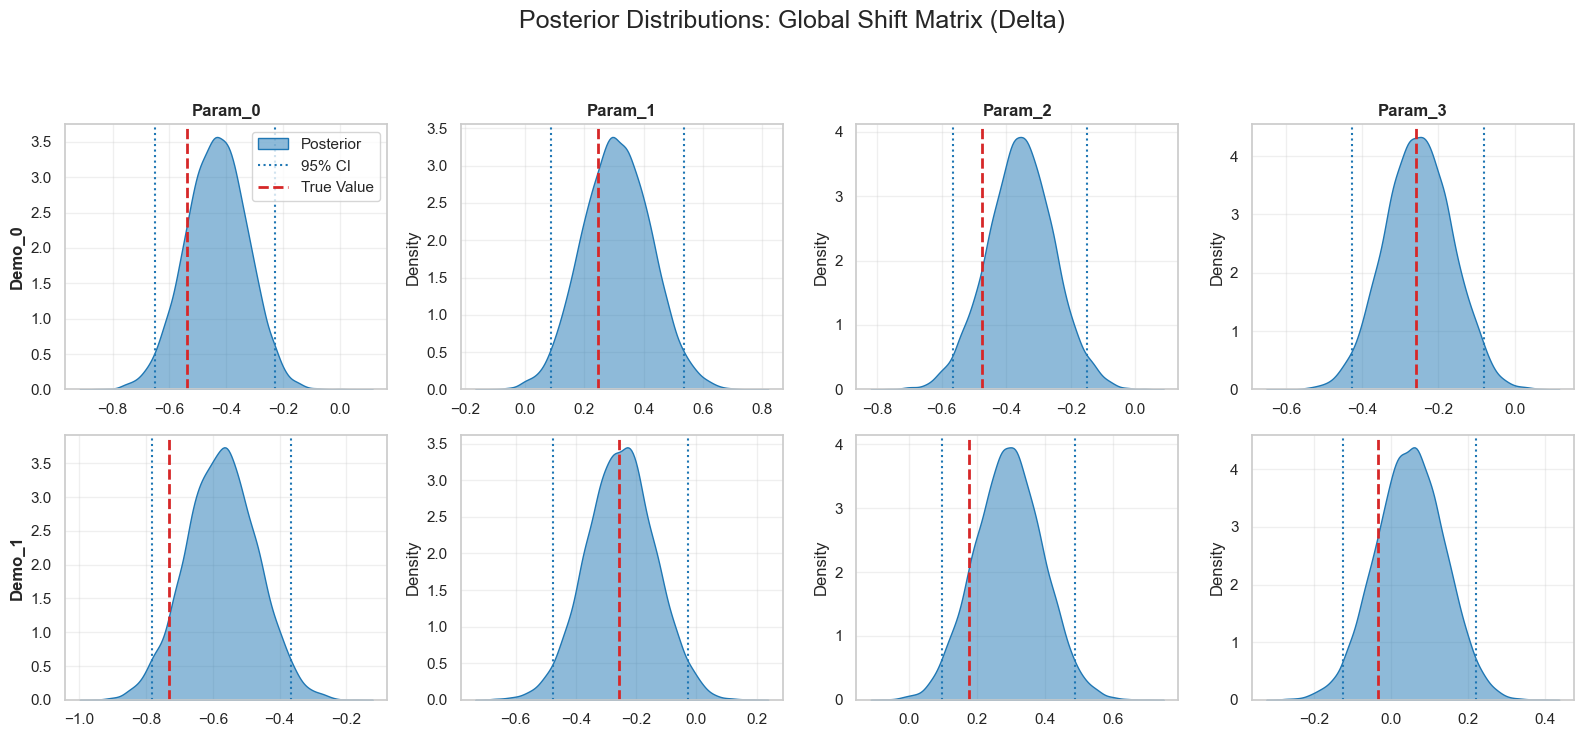

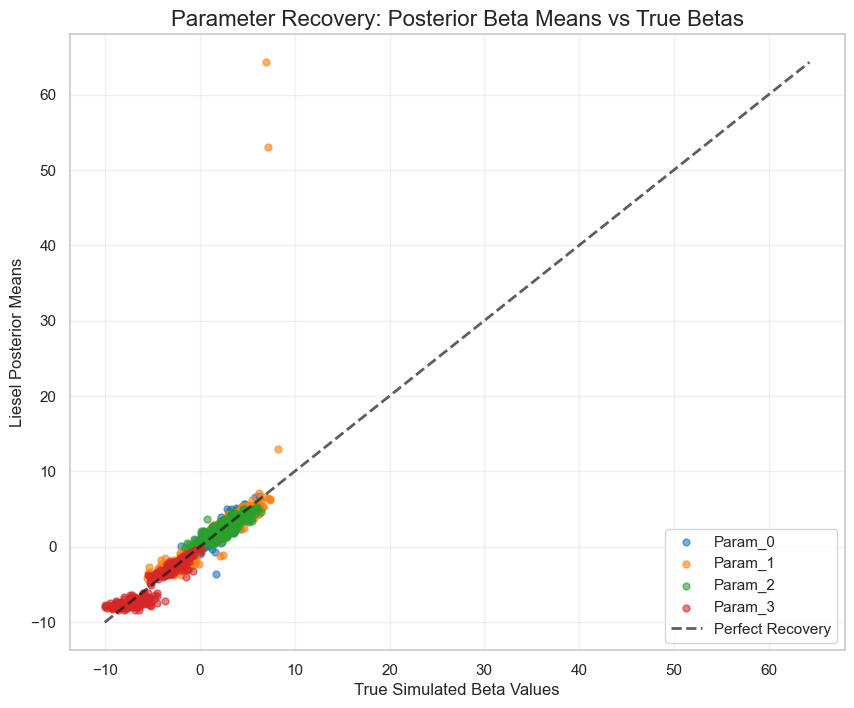


Household-level posterior — Unit 0...


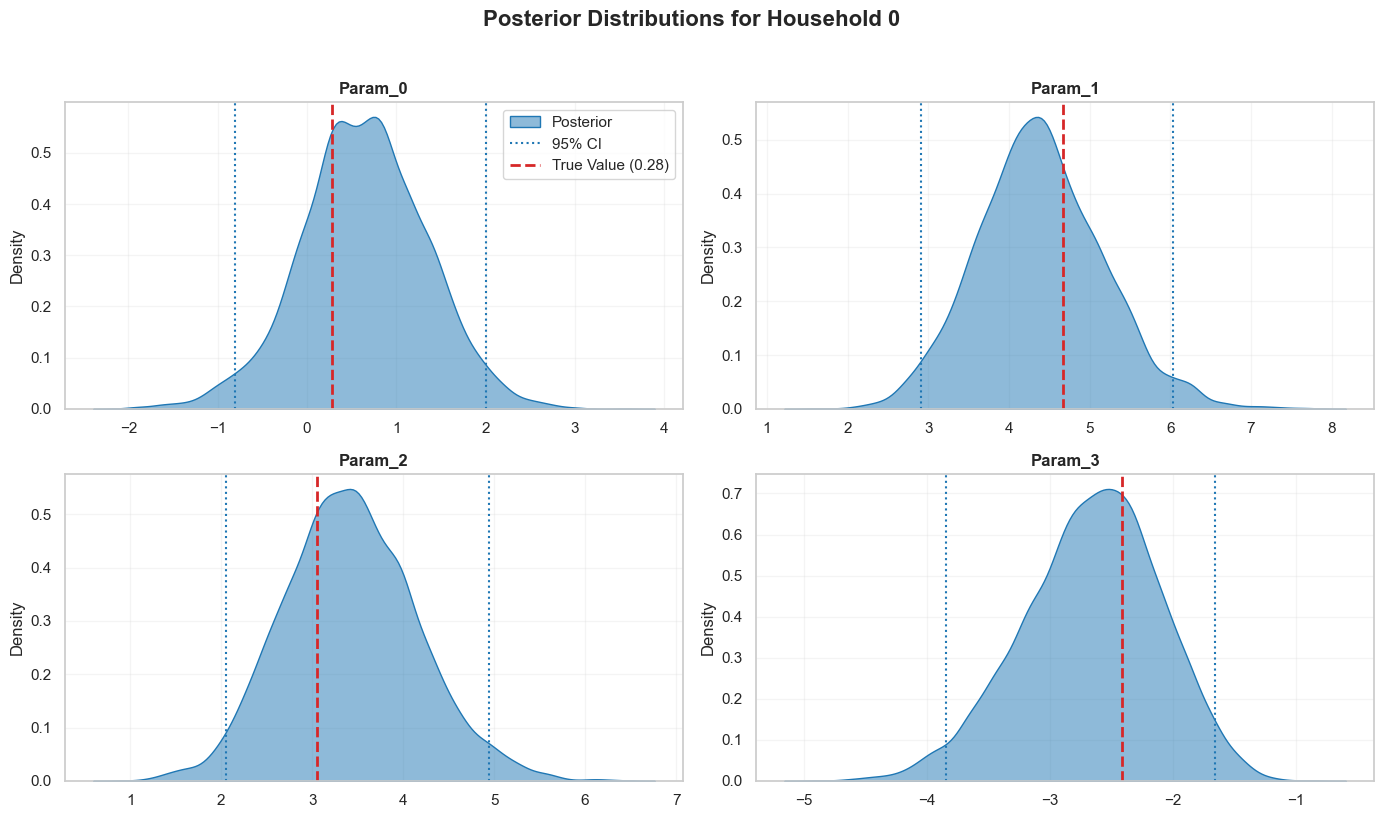


Household-level posterior — Unit 299...


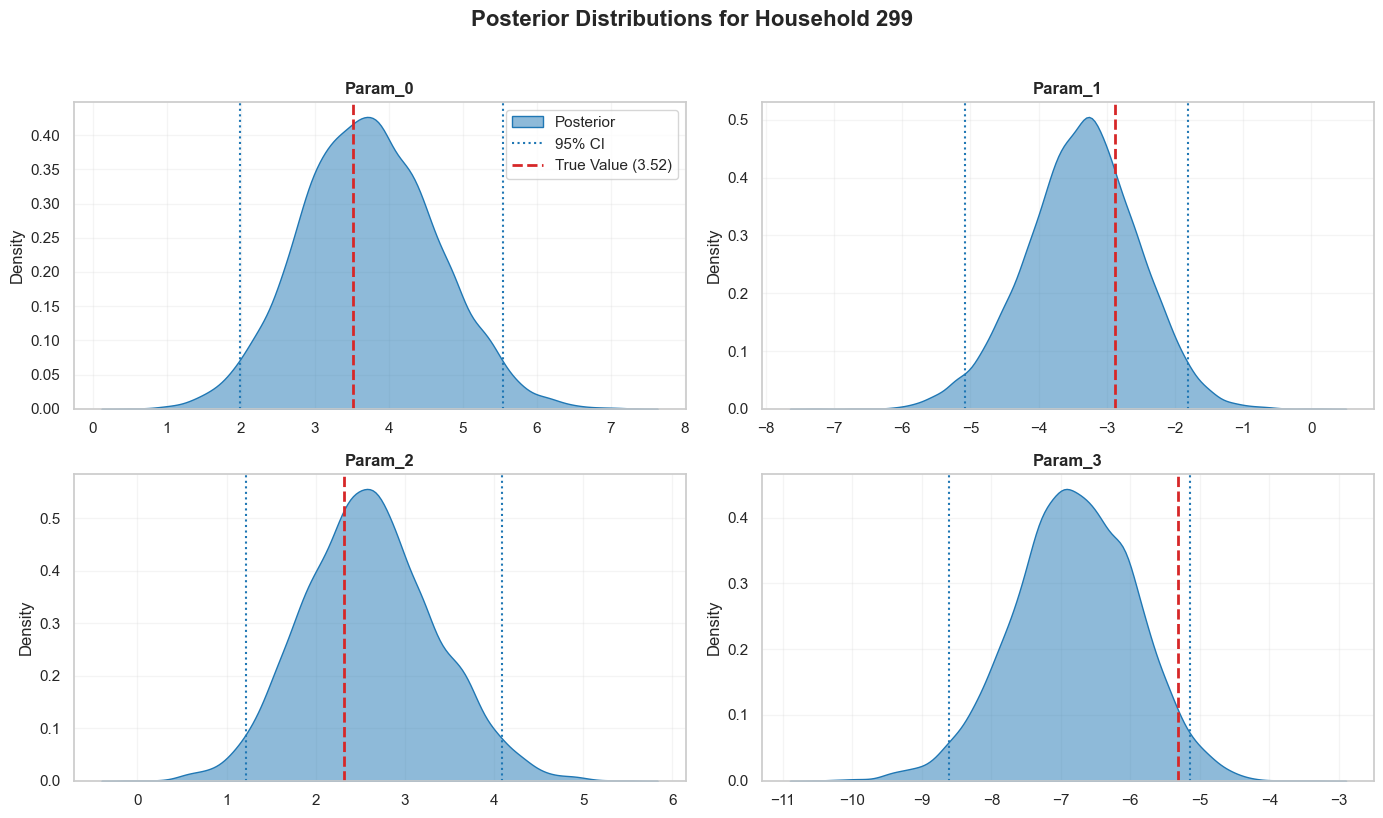


=== pvec diagnostics ===
    K_MODEL=5 fitted, K_TRUE=2 in data


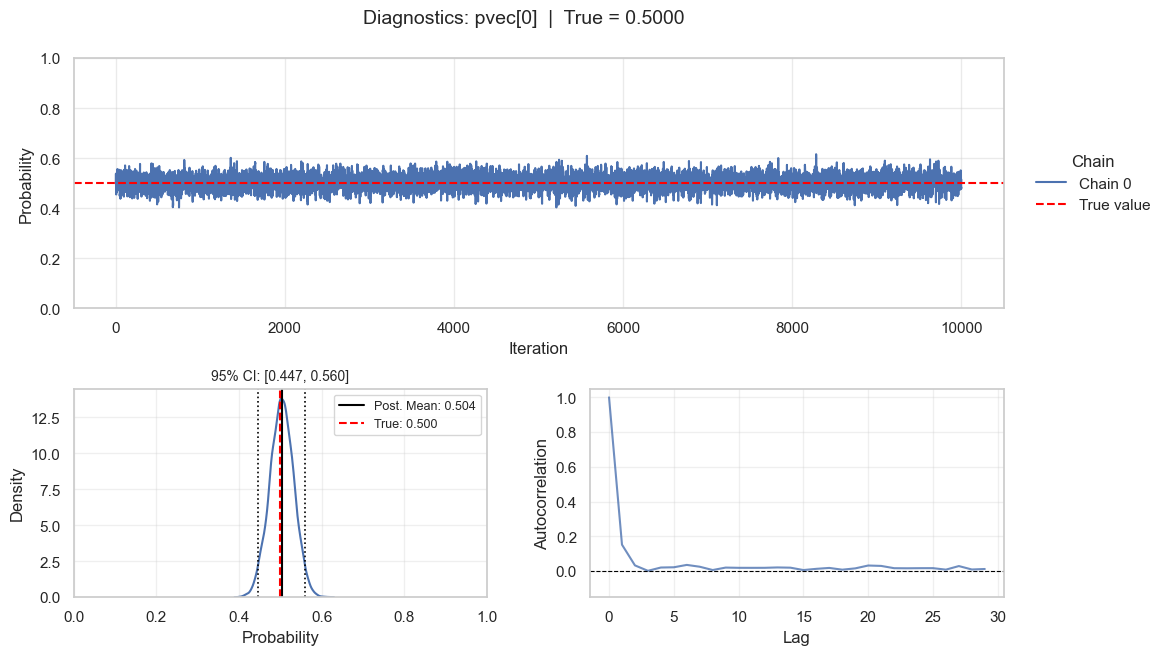

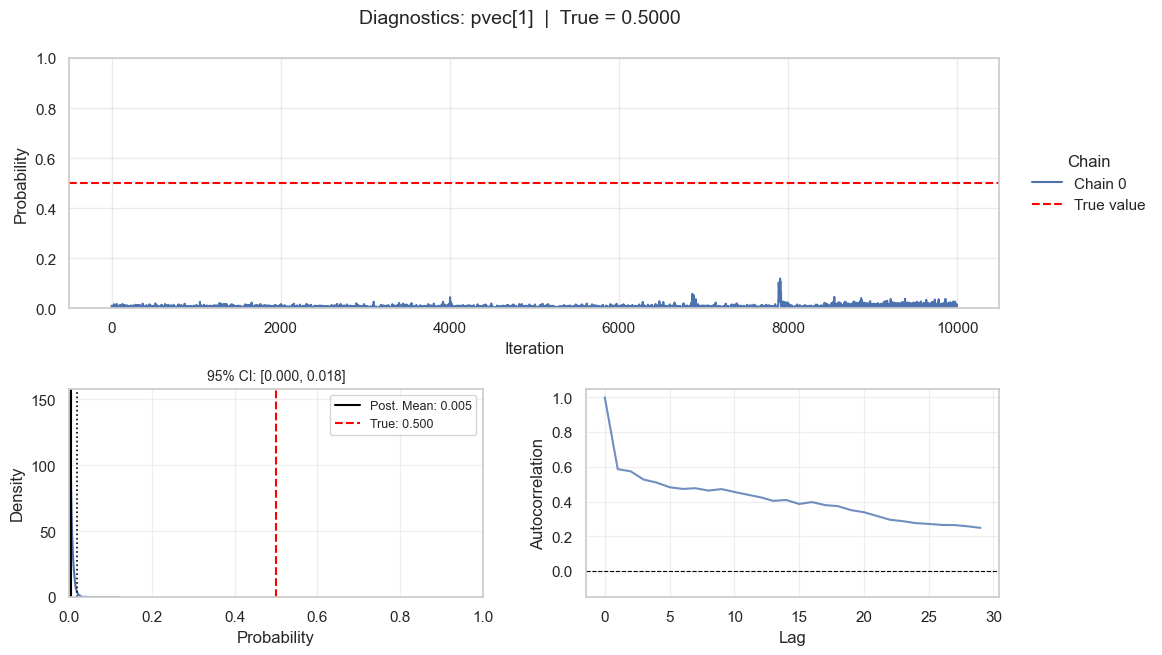

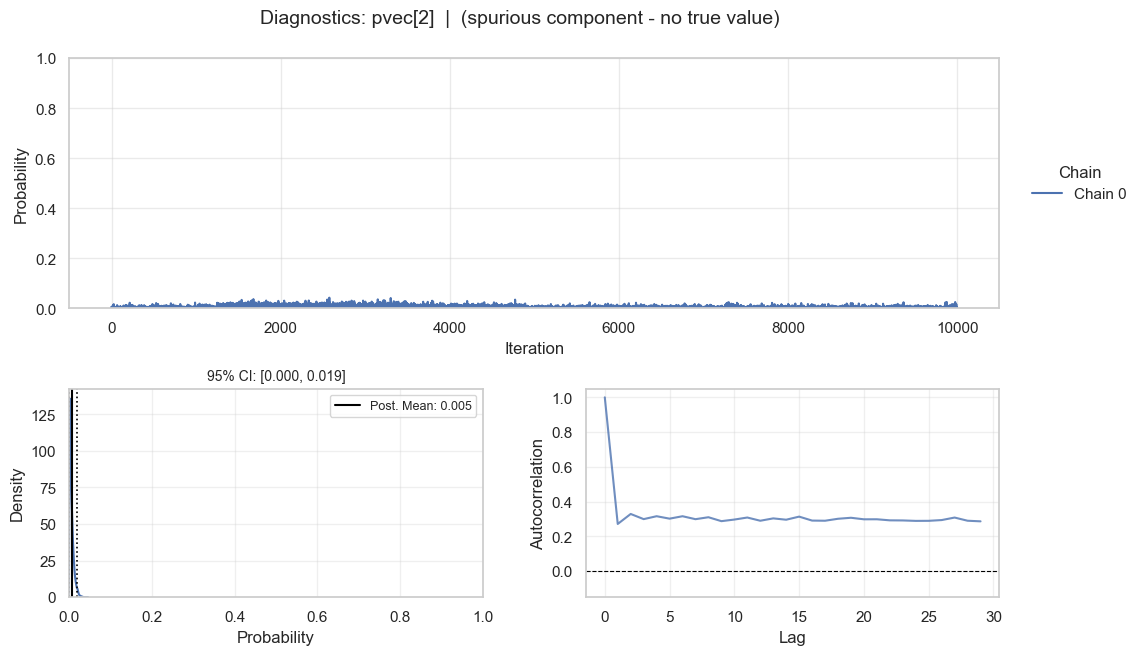

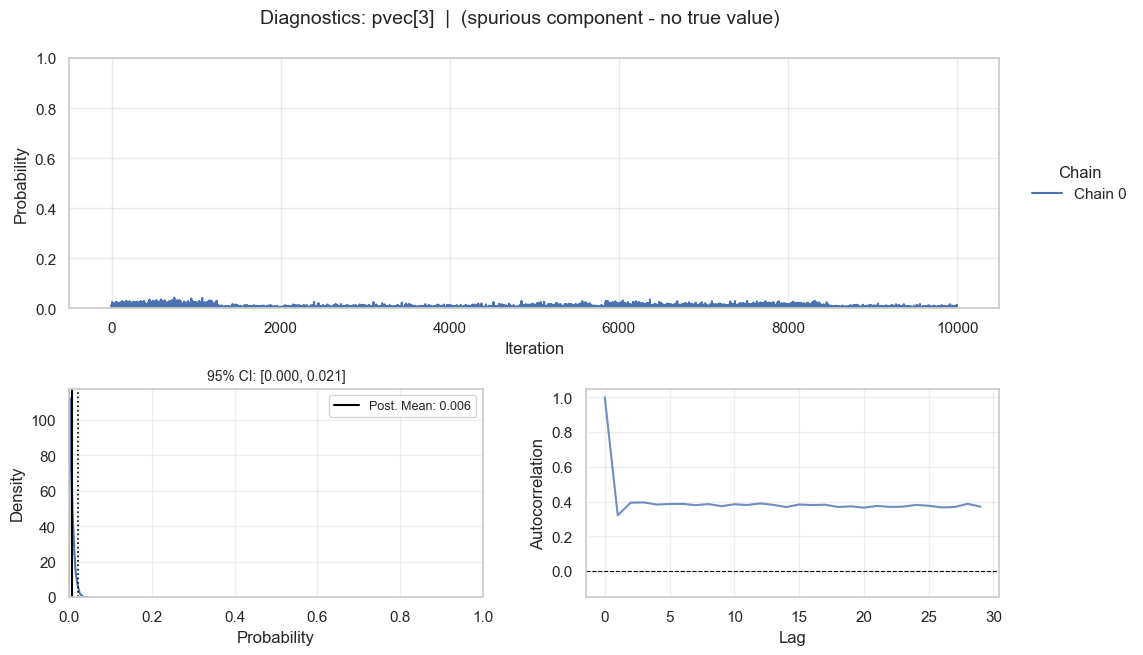

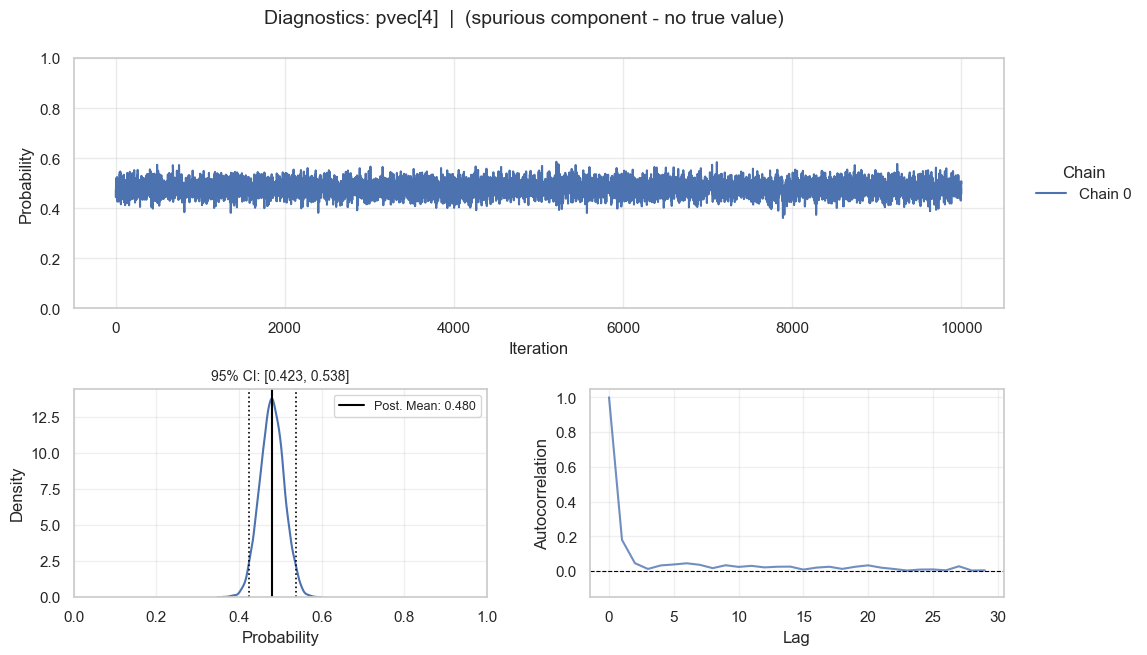


=== pvec: Posterior Summary ===


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%,True_pvec,True_in_CI
Component,,,,,,
0,0.5037041,0.028972413,0.4466,0.5599,0.5,True
1,0.0047907415,0.0061246986,0.0001,0.0182,0.5,False
2,0.0052786227,0.00506125,0.0001,0.0190,NaN,NaN
3,0.006201731,0.005687745,0.0001,0.0212,NaN,NaN
4,0.48002478,0.029196244,0.4234,0.5375,NaN,NaN


In [5]:
# Cell 5 : Diagnostics & Analysis
# Rule: K_MODEL drives every loop; K_TRUE only guards ground-truth overlays.

P       = choice_data["n_params"]
D       = choice_data.get("n_demos", 0)
n_units = choice_data["n_units"]

param_names = [f"Param_{i}" for i in range(P)]
demo_names  = [f"Demo_{i}"  for i in range(D)]

# Ground truth (each may have only K_TRUE component-rows)
t_sigma = choice_data.get("TRUE_SIGMA_K")
t_delta = choice_data.get("TRUE_DELTA")
t_beta  = choice_data.get("TRUE_BETA")
t_pvec  = choice_data.get("TRUE_PVEC")
t_mu    = choice_data.get("TRUE_MU_K")
t_inds  = choice_data.get("TRUE_INDICATORS")

samples = posterior_samples

# ── 1. Latent Cholesky traces (all K_MODEL components) ──
for k in range(K_MODEL):
    plot_cholesky_traces(samples, n_params=P, k_idx=k)

# ── 2. Covariance matrices ──
print("\nRecovering Covariance Matrices (Sigma_k)...")
sigma_samples = recover_covariance_matrices(samples["sigma_inv_chol_k_latent"])

for k in range(K_MODEL):
    # truth only exists for k < K_TRUE; pass None for spurious components
    true_sigma_k = t_sigma[k] if (t_sigma is not None and k < K_TRUE) else None

    emp_sigma = None
    if t_inds is not None and t_beta is not None and k < K_TRUE:
        comp_betas = t_beta[t_inds == k]
        if len(comp_betas) > 1:
            emp_sigma = np.cov(comp_betas, rowvar=False)

    plot_final_covariance_complete(
        samples=sigma_samples[:, :, k, :, :],
        true_matrix=true_sigma_k,
        empirical_matrix=emp_sigma,
        component_idx=k,
    )

# ── 3. Component means (mu_k) ──
summarize_mu_k(samples["mu_k"], K=K_MODEL, P=P, param_names=param_names,
               true_mu=t_mu, K_true=K_TRUE)

# ── 3b. Delta (unaffected by K) ──
if D > 0 and "Delta" in samples:
    raw_delta_samples = samples["Delta"]
    delta_flat = raw_delta_samples.reshape(-1, D, P)

    print("\n=== Goose-Style Diagnostics for Delta ===")
    for i in range(D):
        for j in range(P):
            plot_goose_style_diagnostics(
                raw_delta_samples, demo_idx=i, param_idx=j,
                demo_name=demo_names[i], param_name=param_names[j],
            )

    generate_delta_summaries(delta_flat, param_names, demo_names, true_delta=t_delta)
    plot_delta_distributions(delta_flat, param_names, demo_names, true_delta=t_delta)

# ── 4. Household betas (unaffected by K) ──
plot_beta_scatter(samples["beta_i"], t_beta, param_names)

liesel_beta_full = samples["beta_i"].reshape(-1, n_units, P)

print("\nHousehold-level posterior — Unit 0...")
plot_beta_distributions(
    samples=liesel_beta_full[:, 0, :],
    p_names=param_names,
    title_prefix="Posterior Distributions for Household 0",
    true_vals=t_beta[0, :] if t_beta is not None else None,
)

print(f"\nHousehold-level posterior — Unit {n_units - 1}...")
plot_beta_distributions(
    samples=liesel_beta_full[:, -1, :],
    p_names=param_names,
    title_prefix=f"Posterior Distributions for Household {n_units - 1}",
    true_vals=t_beta[-1, :] if t_beta is not None else None,
)

# ── 5. Component probabilities (pvec) ──
print("\n=== pvec diagnostics ===")
print(f"    K_MODEL={K_MODEL} fitted, K_TRUE={K_TRUE} in data")

if "pvec" in samples:
    pvec_samples = samples["pvec"]
elif "pvec_latent" in samples:
    pvec_samples = tfb.SoftmaxCentered().forward(samples["pvec_latent"])
else:
    raise KeyError("Neither 'pvec' nor 'pvec_latent' found in posterior samples.")

plot_pvec_diagnostics(pvec_samples, K=K_MODEL, true_pvec=t_pvec, K_true=K_TRUE)
summarize_pvec(pvec_samples, K=K_MODEL, true_pvec=t_pvec, K_true=K_TRUE)


In [6]:
# Cell 6 : Export Posterior for Marginal-Density Comparison
# Exports all K_MODEL components (no ground truth involved here).

export_filename = f"{SCENARIO_NAME}_K{K_MODEL}_liesel.pkl"
output_folder   = "results"   # created relative to the notebook's working dir

export_posterior_to_pickle(
    samples=posterior_samples,
    K=K_MODEL,
    P=choice_data["n_params"],
    filename=export_filename,
    output_dir=output_folder,
)


Preparing posterior samples for export...
 - R (total posterior draws) : 10000
 - K (model components)      : 5
 - P (parameters)            : 4
 - pvec mean per component   : [0.5037 0.0048 0.0053 0.0062 0.48  ]

Saved 5-component draws -> c:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\1_chain\2_comp\NUTS\results\2comp_equal_K5_liesel.pkl
   mu    shape : (10000, 5, 4)
   sigma shape : (10000, 5, 4, 4)
   std   shape : (10000, 5, 4)
   pvec  shape : (10000, 5)
